# Milestone 3 - Modelação e Avaliação (Objetivo 3)

Neste notebook é realizada uma análise de clustering com o objetivo de identificar e caracterizar perfis distintos de colaboradores com base nas variáveis relevantes do dataset IBM HR Analytics Employee Attrition & Performance.

Esta etapa enquadra-se nas fases de Modelling e Evaluation da metodologia CRISP-DM, complementando a modelação supervisionada desenvolvida nos objetivos anteriores, ao permitir uma análise exploratória avançada da estrutura dos dados.

O objetivo principal deste notebook consiste em aplicar técnicas de clustering para segmentar os colaboradores em grupos homogéneos, determinando o número ótimo de clusters com base no método do cotovelo (Elbow Method) e na métrica de Silhouette Score, garantindo um valor médio de Silhouette superior a 0,50.

Importa salientar que, ao contrário dos modelos supervisionados, esta abordagem não utiliza a variável alvo (Attrition), focando-se exclusivamente na identificação de padrões e estruturas latentes nos dados.

Após a preparação dos dados para clustering, esta fase tem como propósito:

- Selecionar e preparar as variáveis relevantes para a análise de agrupamento;
- Aplicar diversos algoritmos de clustering para segmentação dos colaboradores;
- Determinar o número ótimo de clusters através do método do cotovelo (Elbow Method);
- Avaliar a qualidade dos agrupamentos através do Silhouette Score, garantindo um nível adequado de coesão e separação entre clusters;
- Analisar a distribuição dos colaboradores pelos diferentes grupos identificados;
- Caracterizar estatisticamente cada cluster, com base nas variáveis mais relevantes;
- Interpretar os perfis obtidos, identificando padrões distintos de comportamento organizacional;
- Relacionar, de forma exploratória, os clusters com a variável Attrition, de modo a avaliar se existem perfis com maior propensão ao abandono.

A análise de clustering permite identificar segmentos de colaboradores com características semelhantes, proporcionando uma visão complementar à modelação supervisionada. Esta abordagem pode apoiar a definição de estratégias diferenciadas de gestão de recursos humanos, adaptadas aos diferentes perfis identificados.

**Autores: Luís Figueira, Martim Ferreira e Mateus Afonso (Figueira,L., Afonso, M. e Ferreira, M.)**

## 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)

import warnings
warnings.filterwarnings('ignore')
print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 2. Carregamento dos Datasets

In [2]:
# Dataset de clustering (sem variável alvo)
base_cluster = 'https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/Objetivo3/treino'
X = pd.read_csv(f'{base_cluster}/X.csv')

# Dataset completo — usado apenas para estratificação do split
url_full = 'https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv'
df_full  = pd.read_csv(url_full)

print(f'Dataset clustering: {X.shape[0]} linhas, {X.shape[1]} colunas')
print(f'Dataset completo:   {df_full.shape[0]} linhas, {df_full.shape[1]} colunas')

Dataset clustering: 1470 linhas, 53 colunas
Dataset completo:   1470 linhas, 62 colunas


## 3. Divisão Treino / Teste (80/20, estratificado por Attrition_bin)

> O `StandardScaler` faz `fit` apenas no treino para evitar *data leakage*.

In [3]:
attrition_strat = df_full['Attrition_bin'].values

X_train, X_test, _, _ = train_test_split(
    X, attrition_strat,
    test_size=0.2,
    random_state=42,
    stratify=attrition_strat
)

print('Divisao treino/teste (80/20, estratificada por Attrition_bin):')
print(f'  Treino: {X_train.shape[0]} amostras  ({X_train.shape[0]/X.shape[0]*100:.0f}%)')
print(f'  Teste:  {X_test.shape[0]} amostras  ({X_test.shape[0]/X.shape[0]*100:.0f}%)')
print(f'\n  Proporcao Attrition no treino: {df_full["Attrition_bin"].iloc[X_train.index].mean()*100:.1f}%')
print(f'  Proporcao Attrition no teste:  {df_full["Attrition_bin"].iloc[X_test.index].mean()*100:.1f}%')

Divisao treino/teste (80/20, estratificada por Attrition_bin):
  Treino: 1176 amostras  (80%)
  Teste:  294 amostras  (20%)

  Proporcao Attrition no treino: 16.2%
  Proporcao Attrition no teste:  16.0%


## 4. Normalização

O `StandardScaler` é ajustado (`.fit_transform`) apenas no treino. No teste aplica-se apenas `.transform` com os parâmetros já aprendidos — sem *data leakage*.

In [4]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('StandardScaler aplicado (fit no treino, transform no teste).')
print(f'  Media treino:  {X_train_scaled.mean():.4f}  (deve ser ~0)')
print(f'  Std   treino:  {X_train_scaled.std():.4f}  (deve ser ~1)')

StandardScaler aplicado (fit no treino, transform no teste).
  Media treino:  0.0000  (deve ser ~0)
  Std   treino:  1.0000  (deve ser ~1)


## 5. Baseline — K-Means k=5

Recalculado com o **mesmo split 80/20 estratificado** para ser diretamente comparável com os candidatos.

> Parâmetros totalmente default — sem `random_state` nem `n_init`.

In [5]:
kmeans_base         = KMeans(n_clusters=5)
clusters_train_base = kmeans_base.fit_predict(X_train_scaled)
clusters_test_base  = kmeans_base.predict(X_test_scaled)

sil_train_base = silhouette_score(X_train_scaled, clusters_train_base)
db_train_base  = davies_bouldin_score(X_train_scaled, clusters_train_base)
ch_train_base  = calinski_harabasz_score(X_train_scaled, clusters_train_base)

sil_test_base  = silhouette_score(X_test_scaled, clusters_test_base)
db_test_base   = davies_bouldin_score(X_test_scaled, clusters_test_base)
ch_test_base   = calinski_harabasz_score(X_test_scaled, clusters_test_base)

print('===== BASELINE — K-Means k=5 =====')
print(f'{"Metrica":<25} {"Treino":>10} {"Teste":>10}')
print(f'{"-"*45}')
print(f'{"Silhouette Score":<25} {sil_train_base:>10.4f} {sil_test_base:>10.4f}')
print(f'{"Davies-Bouldin":<25} {db_train_base:>10.4f} {db_test_base:>10.4f}')
print(f'{"Calinski-Harabasz":<25} {ch_train_base:>10.2f} {ch_test_base:>10.2f}')
print(f'\n  Meta Silhouette > 0.50: {"ATINGIDA" if sil_test_base > 0.50 else "NAO ATINGIDA"}')
print(f'\nDistribuicao clusters — Treino:')
print(pd.Series(clusters_train_base).value_counts().sort_index().to_string())
print(f'\nDistribuicao clusters — Teste:')
print(pd.Series(clusters_test_base).value_counts().sort_index().to_string())

===== BASELINE — K-Means k=5 =====
Metrica                       Treino      Teste
---------------------------------------------
Silhouette Score              0.0790     0.0786
Davies-Bouldin                3.0400     2.8650
Calinski-Harabasz              59.97      16.99

  Meta Silhouette > 0.50: NAO ATINGIDA

Distribuicao clusters — Treino:
0     56
1    306
2    146
3    480
4    188

Distribuicao clusters — Teste:
0     19
1     69
2     36
3    132
4     38


### 5.1 Silhouette Plot — Baseline (Treino)

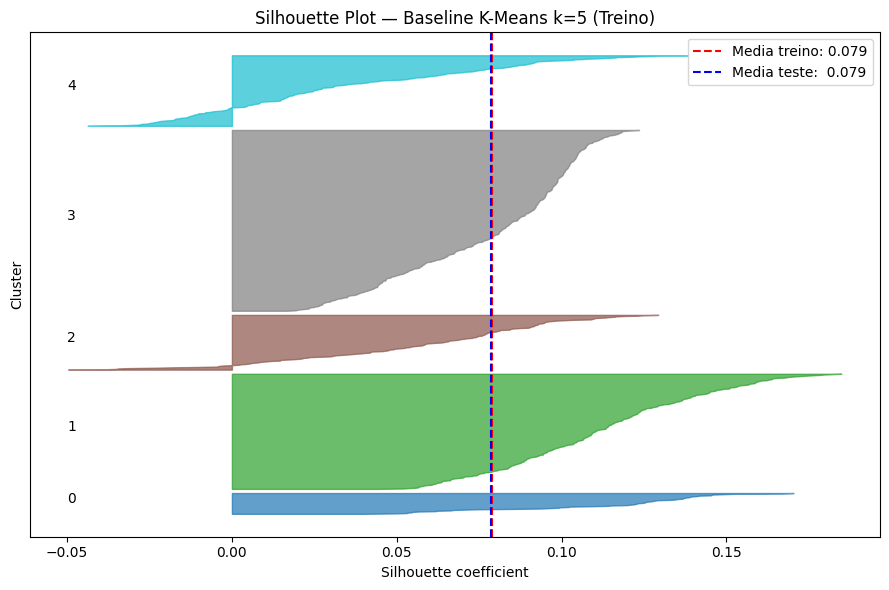

In [6]:
sample_sil_base = silhouette_samples(X_train_scaled, clusters_train_base)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower   = 10
colors_b  = plt.cm.tab10(np.linspace(0, 1, 5))

for i in range(5):
    vals    = sample_sil_base[clusters_train_base == i]
    vals.sort()
    size    = vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors_b[i], edgecolor=colors_b[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_train_base, color='red',  linestyle='--', linewidth=1.5, label=f'Media treino: {sil_train_base:.3f}')
ax.axvline(sil_test_base,  color='blue', linestyle='--', linewidth=1.5, label=f'Media teste:  {sil_test_base:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot — Baseline K-Means k=5 (Treino)')
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('silhouette_plot_baseline_split.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Visualização PCA — Baseline Treino vs. Teste

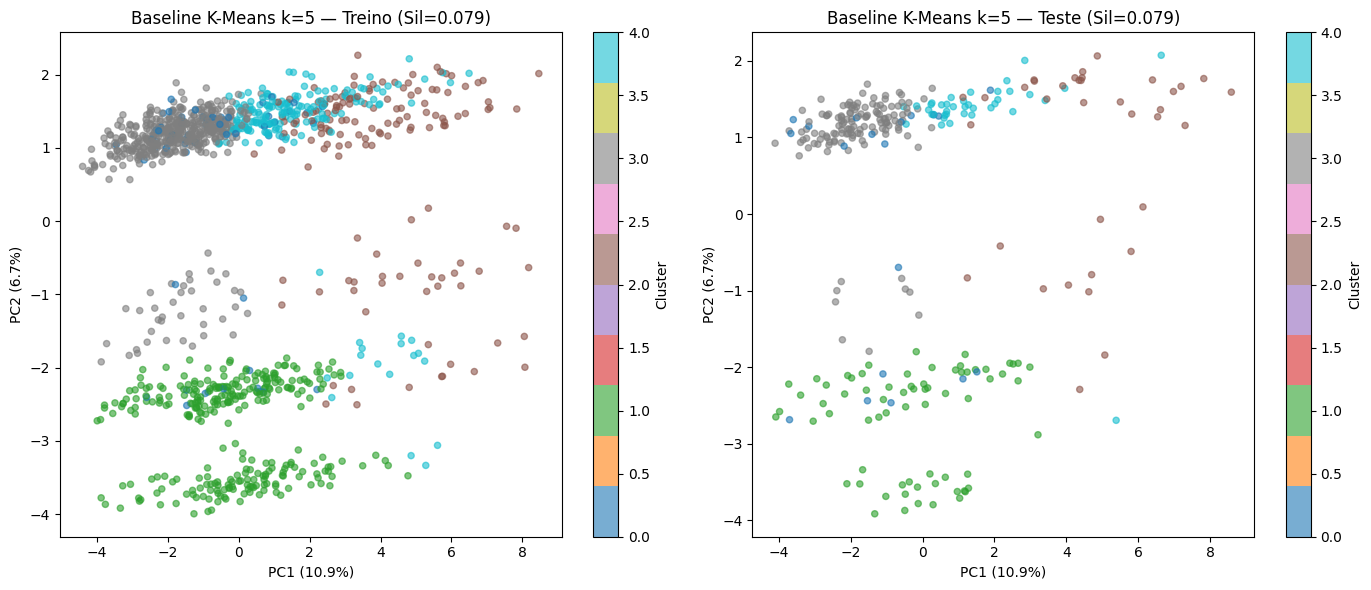

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA
pca_base = PCA(n_components=2, random_state=42)
X_train_pca_base = pca_base.fit_transform(X_train_scaled)
X_test_pca_base = pca_base.transform(X_test_scaled)
var_base = pca_base.explained_variance_ratio_

# Figura
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Treino
sc1 = axes[0].scatter(
    X_train_pca_base[:, 0],
    X_train_pca_base[:, 1],
    c=clusters_train_base,
    cmap='tab10',
    alpha=0.6,
    s=20
)
axes[0].set_title(f'Baseline K-Means k=5 — Treino (Sil={sil_train_base:.3f})')
axes[0].set_xlabel(f'PC1 ({var_base[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_base[1]*100:.1f}%)')
fig.colorbar(sc1, ax=axes[0], label='Cluster')

# Teste
sc2 = axes[1].scatter(
    X_test_pca_base[:, 0],
    X_test_pca_base[:, 1],
    c=clusters_test_base,
    cmap='tab10',
    alpha=0.6,
    s=20
)
axes[1].set_title(f'Baseline K-Means k=5 — Teste (Sil={sil_test_base:.3f})')
axes[1].set_xlabel(f'PC1 ({var_base[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({var_base[1]*100:.1f}%)')
fig.colorbar(sc2, ax=axes[1], label='Cluster')

fig.tight_layout()

# Guarda primeiro
fig.savefig("pca_baseline_treino_teste.png", dpi=120, bbox_inches="tight")

# Mostra
plt.show()

# Fecha para libertar memória
plt.close(fig)

### 5.3 Distribuição dos Clusters — Baseline Treino vs. Teste

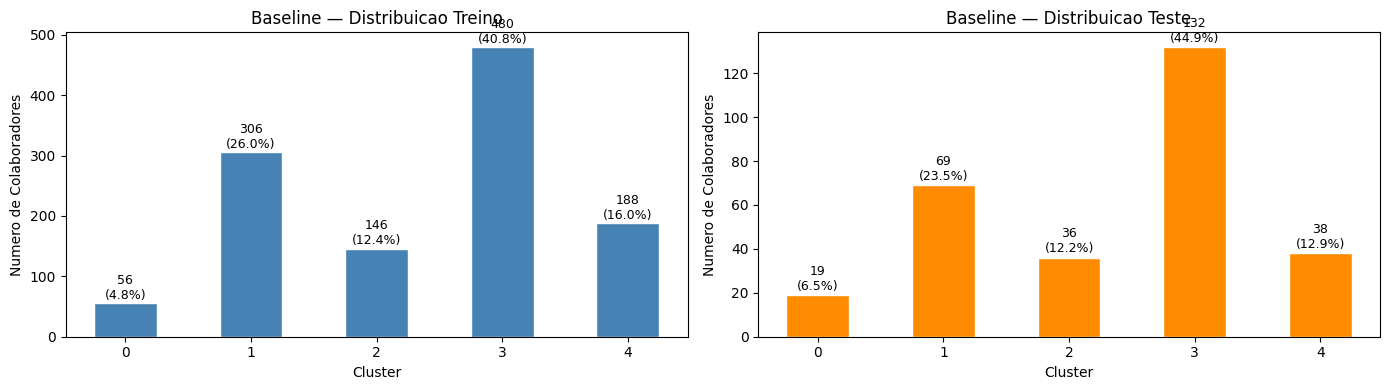

In [8]:
contagem_base_train = pd.Series(clusters_train_base).value_counts().sort_index()
contagem_base_test  = pd.Series(clusters_test_base).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars1 = axes[0].bar(contagem_base_train.index, contagem_base_train.values,
                    color='steelblue', edgecolor='white', width=0.5)
for bar, val in zip(bars1, contagem_base_train.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val}\n({val/len(clusters_train_base)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Numero de Colaboradores')
axes[0].set_title('Baseline — Distribuicao Treino')
axes[0].set_xticks(contagem_base_train.index)

bars2 = axes[1].bar(contagem_base_test.index, contagem_base_test.values,
                    color='darkorange', edgecolor='white', width=0.5)
for bar, val in zip(bars2, contagem_base_test.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({val/len(clusters_test_base)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Numero de Colaboradores')
axes[1].set_title('Baseline — Distribuicao Teste')
axes[1].set_xticks(contagem_base_test.index)

plt.tight_layout()
plt.savefig('distribuicao_baseline_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Candidato 1 — K-Means Otimizado

Pesquisa do k ótimo por Silhouette Score no conjunto de treino, seguida de treino do modelo final e avaliação no teste.


### 6.1 Pesquisa do k ótimo — Elbow + Silhouette (Treino)

In [9]:
K_RANGE      = range(2, 11)
resultados_k = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    resultados_k.append({
        'k':                 k,
        'Inercia':           km.inertia_,
        'Silhouette':        silhouette_score(X_train_scaled, labels),
        'Davies-Bouldin':    davies_bouldin_score(X_train_scaled, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_train_scaled, labels),
    })

df_k     = pd.DataFrame(resultados_k).round(4)
melhor_k = int(df_k.loc[df_k['Silhouette'].idxmax(), 'k'])

print('Tabela de metricas por k (treino):')
display(df_k)
print(f'\nMelhor k por Silhouette: {melhor_k}  '
      f'({df_k.loc[df_k["k"]==melhor_k, "Silhouette"].values[0]:.4f})')

Tabela de metricas por k (treino):


,k,Inercia,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,57689.9738,0.1056,3.1380,94.3846
1,3,54213.0982,0.0769,2.9598,87.7904
2,4,51365.3072,0.0895,2.5451,83.3784
3,5,49770.9766,0.0827,2.9037,73.8597
4,6,48644.8737,0.0713,2.9515,65.8209
5,7,47096.0356,0.0816,2.7996,63.0137
6,8,45658.9897,0.1017,2.4666,60.9156
7,9,44627.2094,0.0982,2.4614,57.8594
8,10,43101.7836,0.1092,2.4058,57.7903



Melhor k por Silhouette: 10  (0.1092)


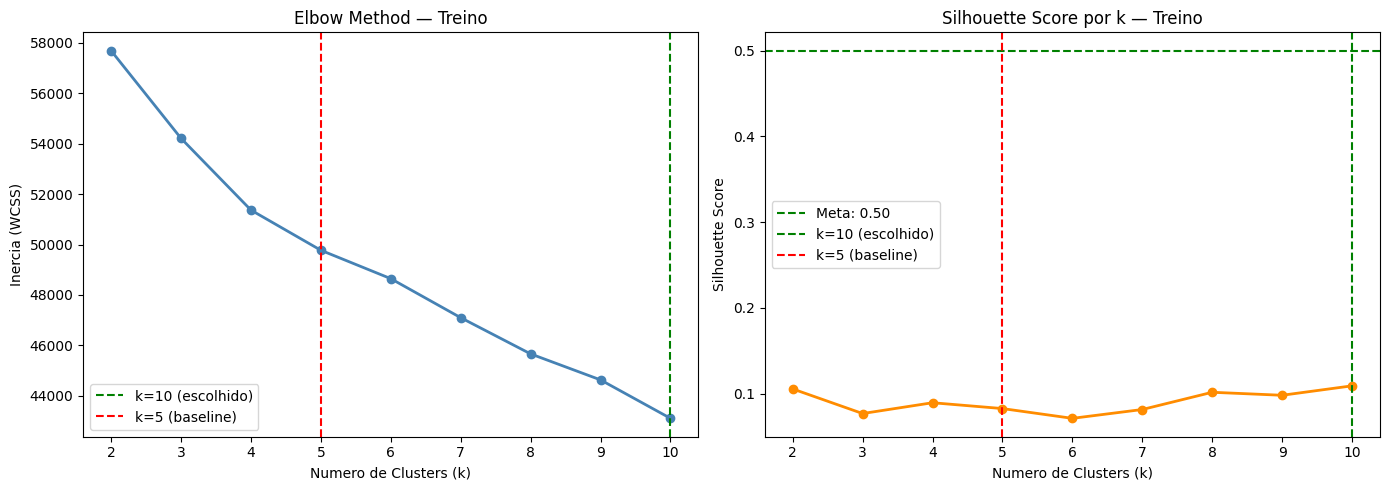

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_k['k'], df_k['Inercia'], marker='o', color='steelblue', linewidth=2)
axes[0].axvline(melhor_k, color='green', linestyle='--', linewidth=1.5, label=f'k={melhor_k} (escolhido)')
axes[0].axvline(5, color='red', linestyle='--', linewidth=1.5, label='k=5 (baseline)')
axes[0].set_xlabel('Numero de Clusters (k)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Elbow Method — Treino')
axes[0].set_xticks(list(K_RANGE))
axes[0].legend()

axes[1].plot(df_k['k'], df_k['Silhouette'], marker='o', color='darkorange', linewidth=2)
axes[1].axhline(0.50, color='green', linestyle='--', linewidth=1.5, label='Meta: 0.50')
axes[1].axvline(melhor_k, color='green', linestyle='--', linewidth=1.5, label=f'k={melhor_k} (escolhido)')
axes[1].axvline(5, color='red', linestyle='--', linewidth=1.5, label='k=5 (baseline)')
axes[1].set_xlabel('Numero de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k — Treino')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_pesquisa_k.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Treino do Modelo Final e Métricas Treino vs. Teste

In [11]:
kmeans_final      = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
clusters_train_km = kmeans_final.fit_predict(X_train_scaled)
clusters_test_km  = kmeans_final.predict(X_test_scaled)

sil_train_km = silhouette_score(X_train_scaled, clusters_train_km)
db_train_km  = davies_bouldin_score(X_train_scaled, clusters_train_km)
ch_train_km  = calinski_harabasz_score(X_train_scaled, clusters_train_km)

sil_test_km  = silhouette_score(X_test_scaled, clusters_test_km)
db_test_km   = davies_bouldin_score(X_test_scaled, clusters_test_km)
ch_test_km   = calinski_harabasz_score(X_test_scaled, clusters_test_km)

print(f'===== K-MEANS k={melhor_k} — TREINO vs. TESTE =====')
print(f'{"Metrica":<25} {"Treino":>10} {"Teste":>10} {"Diferenca":>12}')
print(f'{"-"*57}')
print(f'{"Silhouette Score":<25} {sil_train_km:>10.4f} {sil_test_km:>10.4f} {abs(sil_train_km-sil_test_km):>12.4f}')
print(f'{"Davies-Bouldin":<25} {db_train_km:>10.4f} {db_test_km:>10.4f} {abs(db_train_km-db_test_km):>12.4f}')
print(f'{"Calinski-Harabasz":<25} {ch_train_km:>10.2f} {ch_test_km:>10.2f} {abs(ch_train_km-ch_test_km):>12.2f}')
print(f'\n  Meta Silhouette > 0.50 (Treino): {"ATINGIDA" if sil_train_km > 0.50 else "NAO ATINGIDA"}')
print(f'  Meta Silhouette > 0.50 (Teste):  {"ATINGIDA" if sil_test_km  > 0.50 else "NAO ATINGIDA"}')
print(f'\nDistribuicao clusters — Treino:')
print(pd.Series(clusters_train_km).value_counts().sort_index().to_string())
print(f'\nDistribuicao clusters — Teste:')
print(pd.Series(clusters_test_km).value_counts().sort_index().to_string())

===== K-MEANS k=10 — TREINO vs. TESTE =====
Metrica                       Treino      Teste    Diferenca
---------------------------------------------------------
Silhouette Score              0.1092     0.1101       0.0009
Davies-Bouldin                2.4058     2.2730       0.1327
Calinski-Harabasz              57.79      16.10        41.69

  Meta Silhouette > 0.50 (Treino): NAO ATINGIDA
  Meta Silhouette > 0.50 (Teste):  NAO ATINGIDA

Distribuicao clusters — Treino:
0     89
1    223
2    209
3     94
4     60
5    108
6     84
7    205
8     41
9     63

Distribuicao clusters — Teste:
0    17
1    45
2    69
3    20
4    23
5    32
6    19
7    41
8    11
9    17


### 6.3 Silhouette Plot — K-Means Otimizado (Treino)

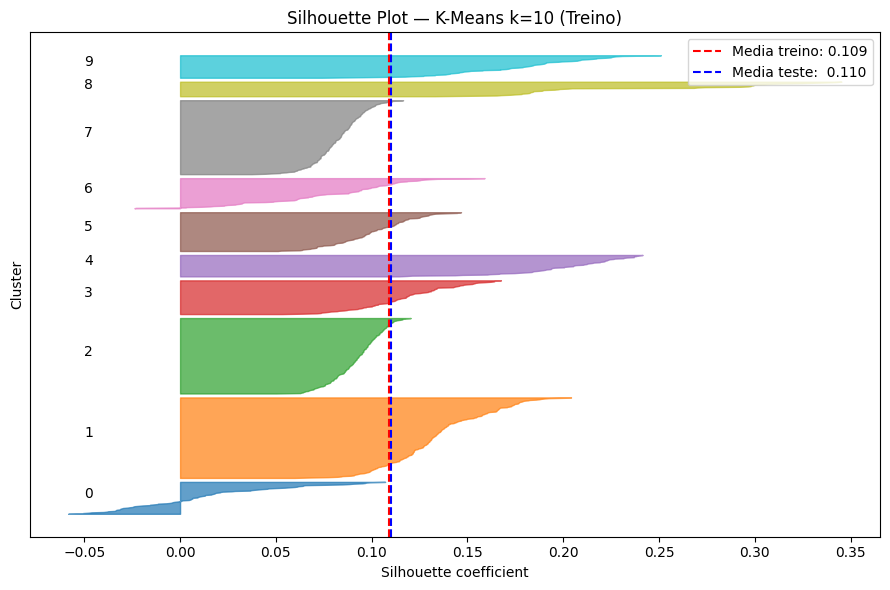

In [12]:
sample_sil_km = silhouette_samples(X_train_scaled, clusters_train_km)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower  = 10
colors   = plt.cm.tab10(np.linspace(0, 1, melhor_k))

for i in range(melhor_k):
    vals    = sample_sil_km[clusters_train_km == i]
    vals.sort()
    size    = vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_train_km, color='red',  linestyle='--', linewidth=1.5, label=f'Media treino: {sil_train_km:.3f}')
ax.axvline(sil_test_km,  color='blue', linestyle='--', linewidth=1.5, label=f'Media teste:  {sil_test_km:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot — K-Means k={melhor_k} (Treino)')
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('silhouette_plot_kmeans_otimizado.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Visualização PCA — K-Means Treino vs. Teste

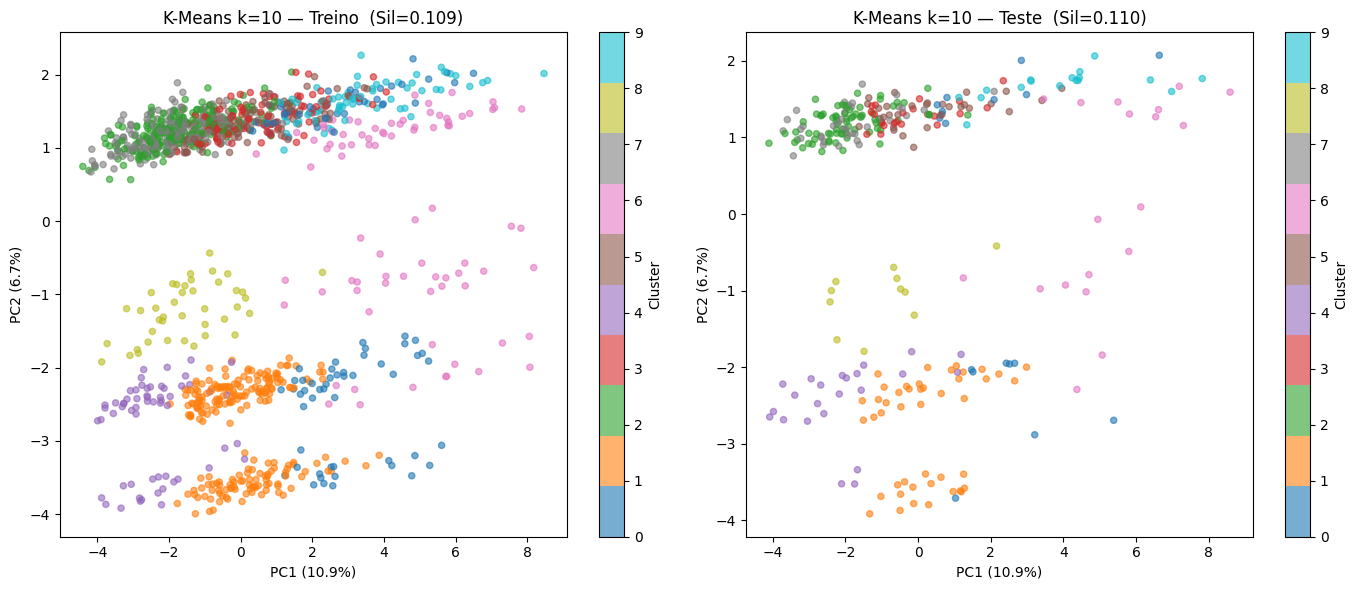

In [13]:
pca         = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
variancia   = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=clusters_train_km, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title(f'K-Means k={melhor_k} — Treino  (Sil={sil_train_km:.3f})')
axes[0].set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

sc2 = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                      c=clusters_test_km, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title(f'K-Means k={melhor_k} — Teste  (Sil={sil_test_km:.3f})')
axes[1].set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('pca_kmeans_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Distribuição dos Clusters — K-Means Treino vs. Teste

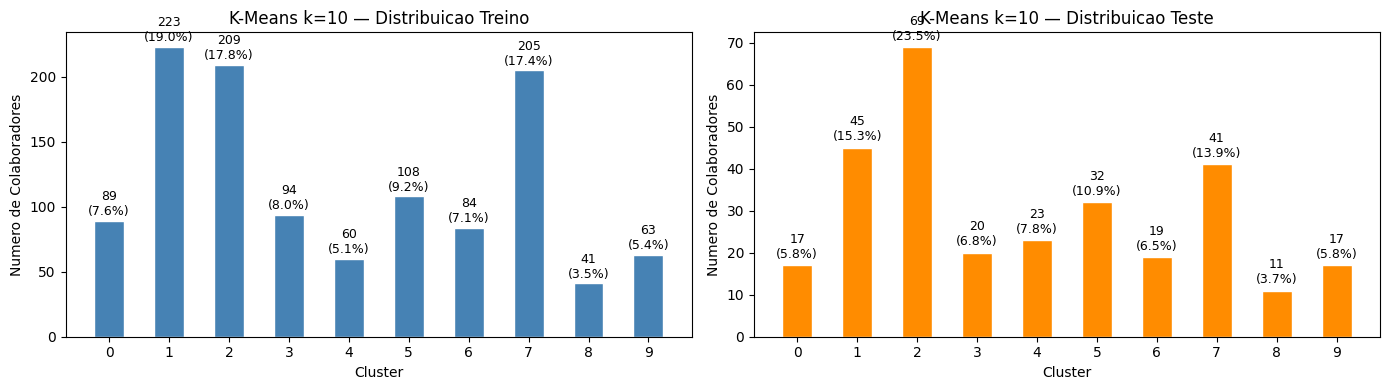

In [14]:
contagem_km_train = pd.Series(clusters_train_km).value_counts().sort_index()
contagem_km_test  = pd.Series(clusters_test_km).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars1 = axes[0].bar(contagem_km_train.index, contagem_km_train.values,
                    color='steelblue', edgecolor='white', width=0.5)
for bar, val in zip(bars1, contagem_km_train.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val}\n({val/len(clusters_train_km)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Numero de Colaboradores')
axes[0].set_title(f'K-Means k={melhor_k} — Distribuicao Treino')
axes[0].set_xticks(contagem_km_train.index)

bars2 = axes[1].bar(contagem_km_test.index, contagem_km_test.values,
                    color='darkorange', edgecolor='white', width=0.5)
for bar, val in zip(bars2, contagem_km_test.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({val/len(clusters_test_km)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Numero de Colaboradores')
axes[1].set_title(f'K-Means k={melhor_k} — Distribuicao Teste')
axes[1].set_xticks(contagem_km_test.index)

plt.tight_layout()
plt.savefig('distribuicao_kmeans_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Candidato 2 — DBSCAN

Algoritmo baseado em densidade que não requer definir k à priori. Identifica automaticamente o número de clusters e marca pontos isolados como ruído.

### 7.1 K-distance Plot — Escolha do eps (Treino)

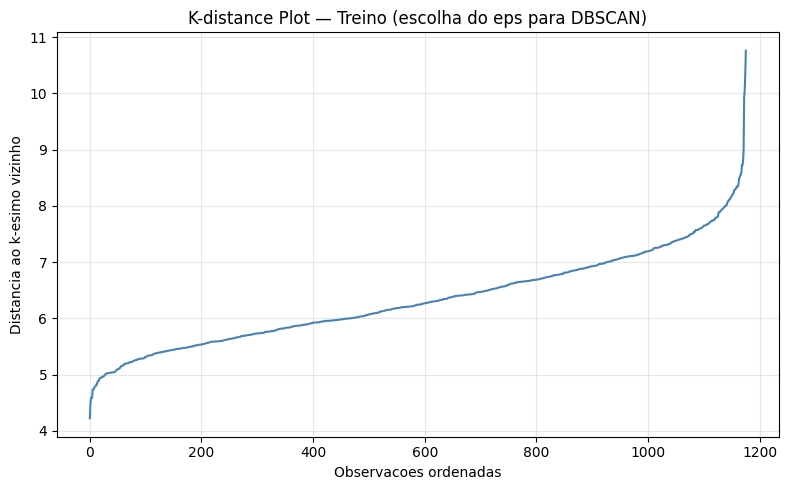

In [15]:
k_nn         = 5
nn           = NearestNeighbors(n_neighbors=k_nn)
nn.fit(X_train_scaled)
distances, _ = nn.kneighbors(X_train_scaled)
distances     = np.sort(distances[:, k_nn - 1])

plt.figure(figsize=(8, 5))
plt.plot(distances, color='steelblue')
plt.title('K-distance Plot — Treino (escolha do eps para DBSCAN)')
plt.xlabel('Observacoes ordenadas')
plt.ylabel('Distancia ao k-esimo vizinho')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_kdistance_treino.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Treino do DBSCAN e Métricas

In [16]:
eps_value         = 8.0
dbscan            = DBSCAN(eps=eps_value, min_samples=5)
clusters_train_db = dbscan.fit_predict(X_train_scaled)

n_clusters_db = len(set(clusters_train_db)) - (1 if -1 in clusters_train_db else 0)
noise_train   = np.sum(clusters_train_db == -1)
noise_pct     = noise_train / len(clusters_train_db) * 100

print(f'DBSCAN treino (eps={eps_value}, min_samples=5):')
print(f'  Clusters encontrados: {n_clusters_db}')
print(f'  Ruido:                {noise_train} pontos ({noise_pct:.1f}%)')
print(f'\nDistribuicao clusters treino:')
print(pd.Series(clusters_train_db).value_counts().sort_index().to_string())

mask_train_db = clusters_train_db != -1

if len(set(clusters_train_db[mask_train_db])) > 1:
    sil_train_db = silhouette_score(X_train_scaled[mask_train_db], clusters_train_db[mask_train_db])
    db_train_db  = davies_bouldin_score(X_train_scaled[mask_train_db], clusters_train_db[mask_train_db])
    ch_train_db  = calinski_harabasz_score(X_train_scaled[mask_train_db], clusters_train_db[mask_train_db])
    print(f'\nMetricas TREINO (sem ruido):')
    print(f'  Silhouette Score:       {sil_train_db:.4f}')
    print(f'  Davies-Bouldin Index:   {db_train_db:.4f}')
    print(f'  Calinski-Harabasz:      {ch_train_db:.2f}')
else:
    print('\nClusters insuficientes para calcular metricas.')
    sil_train_db = db_train_db = ch_train_db = float('nan')

DBSCAN treino (eps=8.0, min_samples=5):
  Clusters encontrados: 3
  Ruido:                10 pontos (0.9%)

Distribuicao clusters treino:
-1      10
 0    1125
 1      23
 2      18

Metricas TREINO (sem ruido):
  Silhouette Score:       0.1761
  Davies-Bouldin Index:   1.5601
  Calinski-Harabasz:      34.61


### 7.3 Aplicação ao Teste via KNN

In [17]:
knn_db           = KNeighborsClassifier(n_neighbors=5)
knn_db.fit(X_train_scaled[mask_train_db], clusters_train_db[mask_train_db])
clusters_test_db = knn_db.predict(X_test_scaled)

print('Distribuicao clusters teste (via KNN):')
print(pd.Series(clusters_test_db).value_counts().sort_index().to_string())

if len(set(clusters_test_db)) > 1:
    sil_test_db = silhouette_score(X_test_scaled, clusters_test_db)
    db_test_db  = davies_bouldin_score(X_test_scaled, clusters_test_db)
    ch_test_db  = calinski_harabasz_score(X_test_scaled, clusters_test_db)
else:
    sil_test_db = db_test_db = ch_test_db = float('nan')

print(f'\n===== DBSCAN — TREINO vs. TESTE =====')
print(f'{"Metrica":<25} {"Treino":>10} {"Teste":>10} {"Diferenca":>12}')
print(f'{"-"*57}')
print(f'{"Silhouette Score":<25} {sil_train_db:>10.4f} {sil_test_db:>10.4f} {abs(sil_train_db-sil_test_db):>12.4f}')
print(f'{"Davies-Bouldin":<25} {db_train_db:>10.4f} {db_test_db:>10.4f} {abs(db_train_db-db_test_db):>12.4f}')
print(f'{"Calinski-Harabasz":<25} {ch_train_db:>10.2f} {ch_test_db:>10.2f} {abs(ch_train_db-ch_test_db):>12.2f}')
print(f'\n  Nota: Teste via KNN (DBSCAN nao tem .predict() nativo)')
print(f'  Ruido no treino: {noise_pct:.1f}%  |  Ruido no teste: 0.0% (KNN)')

Distribuicao clusters teste (via KNN):
0    282
1      8
2      4

===== DBSCAN — TREINO vs. TESTE =====
Metrica                       Treino      Teste    Diferenca
---------------------------------------------------------
Silhouette Score              0.1761     0.1719       0.0042
Davies-Bouldin                1.5601     1.5244       0.0357
Calinski-Harabasz              34.61       8.90        25.71

  Nota: Teste via KNN (DBSCAN nao tem .predict() nativo)
  Ruido no treino: 0.9%  |  Ruido no teste: 0.0% (KNN)


### 7.4 Silhouette Plot — DBSCAN (Treino, sem ruído)

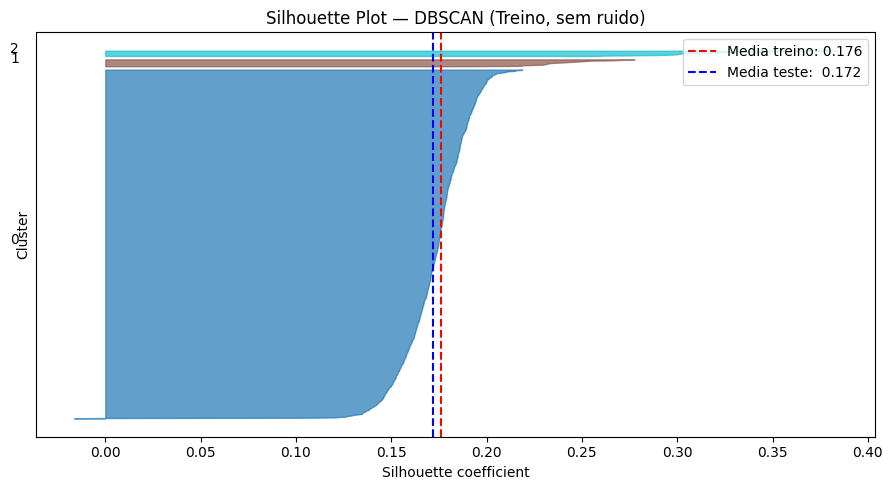

In [18]:
clusters_db_clean = clusters_train_db[mask_train_db]
X_db_clean        = X_train_scaled[mask_train_db]
sample_sil_db     = silhouette_samples(X_db_clean, clusters_db_clean)
unique_db         = sorted(set(clusters_db_clean))

fig, ax = plt.subplots(figsize=(9, 5))
y_lower   = 10
colors_d  = plt.cm.tab10(np.linspace(0, 1, len(unique_db)))

for idx, i in enumerate(unique_db):
    vals    = sample_sil_db[clusters_db_clean == i]
    vals.sort()
    size    = vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors_d[idx], edgecolor=colors_d[idx], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_train_db, color='red',  linestyle='--', linewidth=1.5, label=f'Media treino: {sil_train_db:.3f}')
ax.axvline(sil_test_db,  color='blue', linestyle='--', linewidth=1.5, label=f'Media teste:  {sil_test_db:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot — DBSCAN (Treino, sem ruido)')
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('silhouette_plot_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 Visualização PCA — DBSCAN Treino vs. Teste

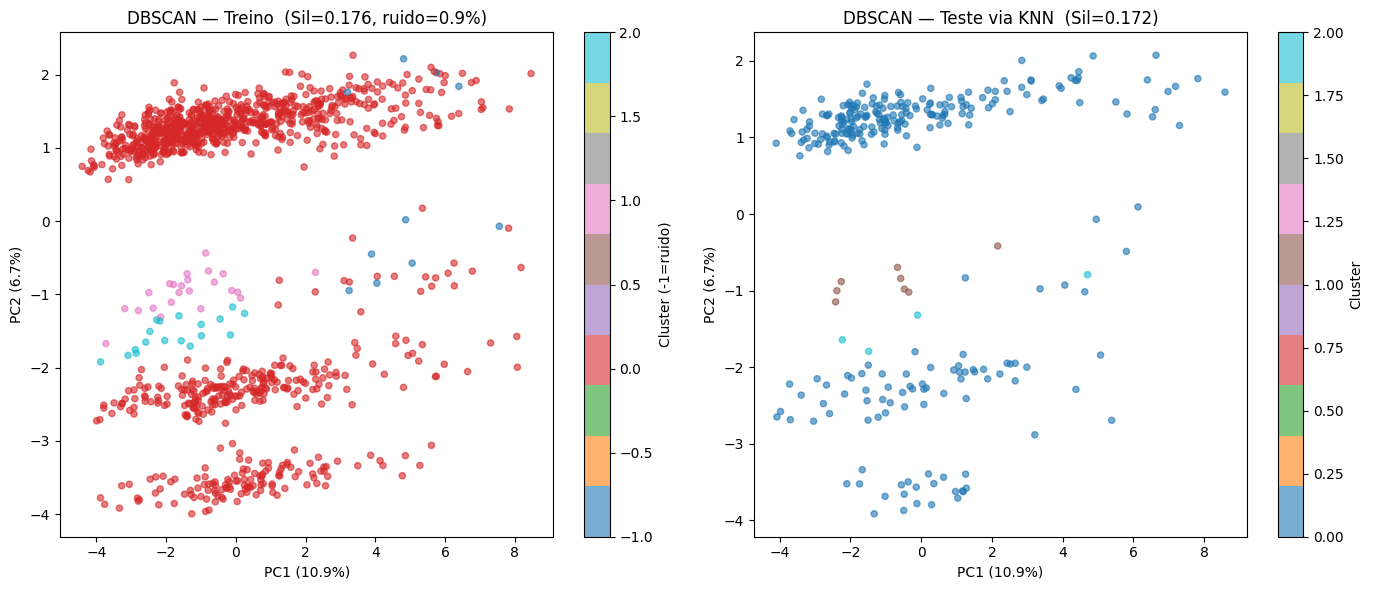

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=clusters_train_db, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title(f'DBSCAN — Treino  (Sil={sil_train_db:.3f}, ruido={noise_pct:.1f}%)')
axes[0].set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[0], label='Cluster (-1=ruido)')

sc2 = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                      c=clusters_test_db, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title(f'DBSCAN — Teste via KNN  (Sil={sil_test_db:.3f})')
axes[1].set_xlabel(f'PC1 ({variancia[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({variancia[1]*100:.1f}%)')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('pca_dbscan_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 Distribuição dos Clusters — DBSCAN Treino vs. Teste

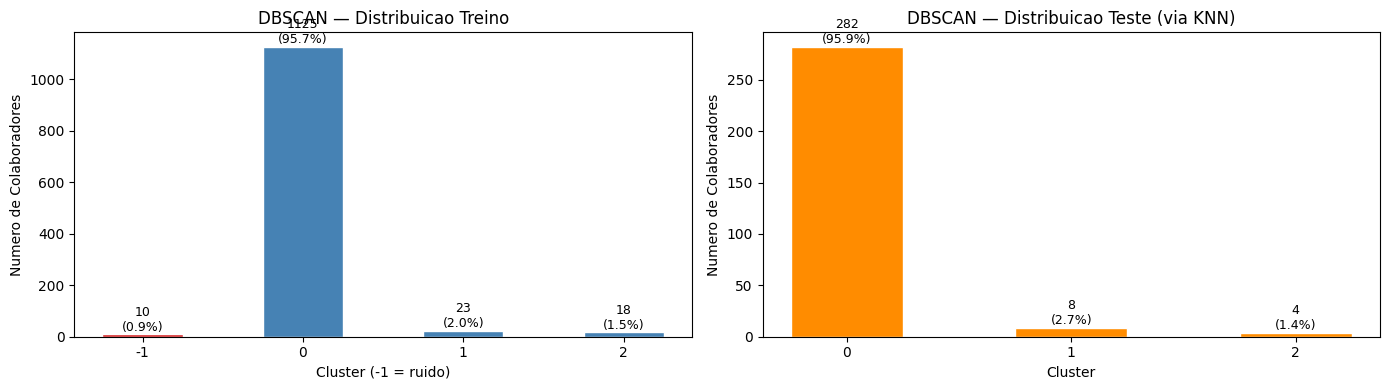

In [20]:
contagem_db_train = pd.Series(clusters_train_db).value_counts().sort_index()
contagem_db_test  = pd.Series(clusters_test_db).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors_dist = ['#d62728' if idx == -1 else 'steelblue'
               for idx in contagem_db_train.index]
bars1 = axes[0].bar(range(len(contagem_db_train)), contagem_db_train.values,
                    color=colors_dist, edgecolor='white', width=0.5)
for bar, val, lbl in zip(bars1, contagem_db_train.values, contagem_db_train.index):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val}\n({val/len(clusters_train_db)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('Cluster (-1 = ruido)')
axes[0].set_ylabel('Numero de Colaboradores')
axes[0].set_title('DBSCAN — Distribuicao Treino')
axes[0].set_xticks(range(len(contagem_db_train)))
axes[0].set_xticklabels(contagem_db_train.index)

bars2 = axes[1].bar(contagem_db_test.index, contagem_db_test.values,
                    color='darkorange', edgecolor='white', width=0.5)
for bar, val in zip(bars2, contagem_db_test.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({val/len(clusters_test_db)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Numero de Colaboradores')
axes[1].set_title('DBSCAN — Distribuicao Teste (via KNN)')
axes[1].set_xticks(contagem_db_test.index)

plt.tight_layout()
plt.savefig('distribuicao_dbscan_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Candidato 3 — GMM

Modelo probabilístico que assume que os dados são gerados a partir de uma mistura de várias distribuições Gaussianas com parâmetros desconhecidos.

### 8.1 Pesquisa do número ótimo de componentes (treino)

In [21]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import numpy as np

COMP_RANGE = range(2, 11)
resultados_gmm = []

for n in COMP_RANGE:
    gmm = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42
    )
    
    gmm.fit(X_train_scaled)
    labels_train = gmm.predict(X_train_scaled)
    
    resultados_gmm.append({
        'n_components': n,
        'Silhouette': silhouette_score(X_train_scaled, labels_train),
        'Davies-Bouldin': davies_bouldin_score(X_train_scaled, labels_train),
        'Calinski-Harabasz': calinski_harabasz_score(X_train_scaled, labels_train),
        'AIC': gmm.aic(X_train_scaled),
        'BIC': gmm.bic(X_train_scaled)
    })

df_gmm = pd.DataFrame(resultados_gmm).round(4)
display(df_gmm)

,n_components,Silhouette,Davies-Bouldin,Calinski-Harabasz,AIC,BIC
0,2,0.0936,3.3890,77.7964,-2920.5112,12131.9450
1,3,0.0800,2.9339,83.2117,-50604.6485,-28023.4291
2,4,0.0852,2.6826,73.8051,-73228.3004,-43118.3179
3,5,0.0853,2.6957,63.2434,-79362.2378,-41723.4923
4,6,0.0671,3.0448,58.5525,-91057.2726,-45889.7640
5,7,0.0764,2.8970,55.8044,-98244.1065,-45547.8348
6,8,0.0784,2.7783,53.1845,-100597.0047,-40371.9699
7,9,0.0946,2.5748,56.3892,-102996.7642,-35242.9663
8,10,0.1083,2.4249,57.1211,-103187.5850,-27905.0241


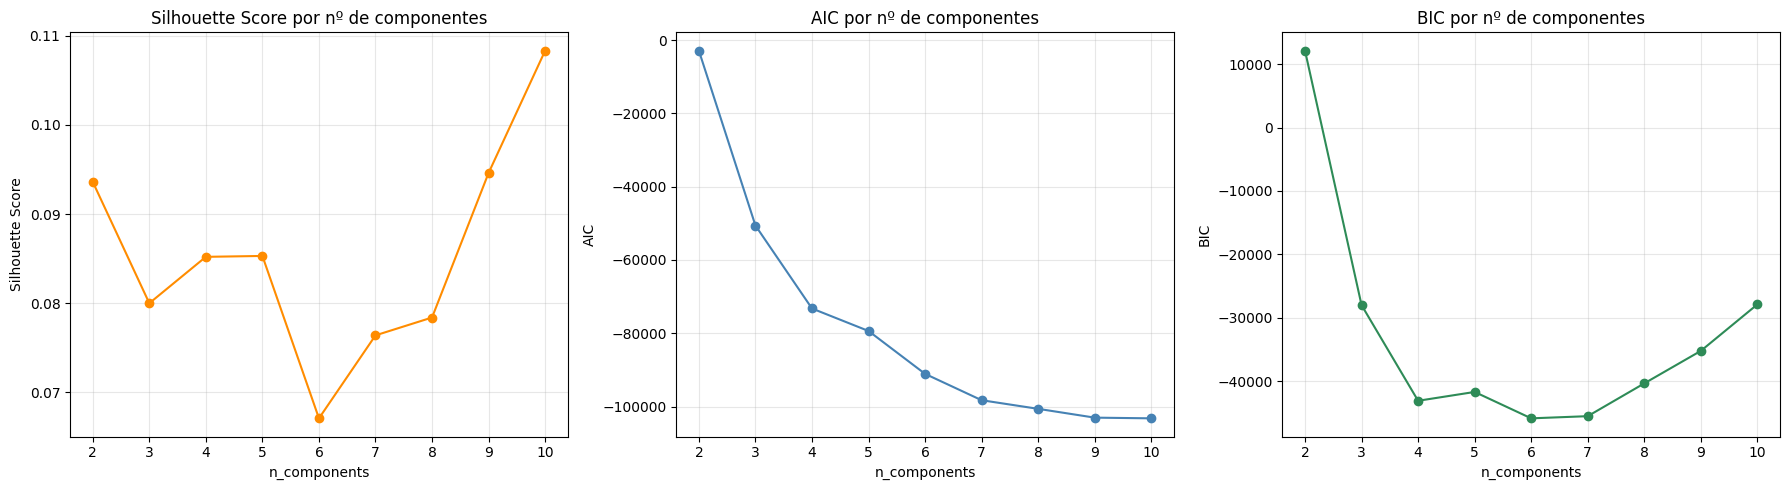

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette
axes[0].plot(df_gmm['n_components'], df_gmm['Silhouette'], marker='o', color='darkorange')
axes[0].set_title('Silhouette Score por nº de componentes')
axes[0].set_xlabel('n_components')
axes[0].set_ylabel('Silhouette Score')
axes[0].grid(alpha=0.3)

# AIC
axes[1].plot(df_gmm['n_components'], df_gmm['AIC'], marker='o', color='steelblue')
axes[1].set_title('AIC por nº de componentes')
axes[1].set_xlabel('n_components')
axes[1].set_ylabel('AIC')
axes[1].grid(alpha=0.3)

# BIC
axes[2].plot(df_gmm['n_components'], df_gmm['BIC'], marker='o', color='seagreen')
axes[2].set_title('BIC por nº de componentes')
axes[2].set_xlabel('n_components')
axes[2].set_ylabel('BIC')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8.2 Treino do modelo final e métricas treino vs teste

In [23]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

# Escolha do melhor número de componentes com base no Silhouette do treino
melhor_n_gmm = int(df_gmm.loc[df_gmm['Silhouette'].idxmax(), 'n_components'])

gmm_final = GaussianMixture(
    n_components=melhor_n_gmm,
    covariance_type='full',
    random_state=42
)

# Fit no treino
gmm_final.fit(X_train_scaled)

# Labels treino e teste
clusters_train_gmm = gmm_final.predict(X_train_scaled)
clusters_test_gmm = gmm_final.predict(X_test_scaled)

# Métricas treino
sil_train_gmm = silhouette_score(X_train_scaled, clusters_train_gmm)
db_train_gmm = davies_bouldin_score(X_train_scaled, clusters_train_gmm)
ch_train_gmm = calinski_harabasz_score(X_train_scaled, clusters_train_gmm)

# Métricas teste
sil_test_gmm = silhouette_score(X_test_scaled, clusters_test_gmm)
db_test_gmm = davies_bouldin_score(X_test_scaled, clusters_test_gmm)
ch_test_gmm = calinski_harabasz_score(X_test_scaled, clusters_test_gmm)

print(f"===== GMM n={melhor_n_gmm} — TREINO vs TESTE =====")
print(f"{'Métrica':<25} {'Treino':>10} {'Teste':>10} {'Diferença':>12}")
print("-" * 60)
print(f"{'Silhouette Score':<25} {sil_train_gmm:>10.4f} {sil_test_gmm:>10.4f} {abs(sil_train_gmm-sil_test_gmm):>12.4f}")
print(f"{'Davies-Bouldin':<25} {db_train_gmm:>10.4f} {db_test_gmm:>10.4f} {abs(db_train_gmm-db_test_gmm):>12.4f}")
print(f"{'Calinski-Harabasz':<25} {ch_train_gmm:>10.2f} {ch_test_gmm:>10.2f} {abs(ch_train_gmm-ch_test_gmm):>12.2f}")

print(f"\nMeta Silhouette > 0.50 (Treino): {'ATINGIDA' if sil_train_gmm > 0.50 else 'NÃO ATINGIDA'}")
print(f"Meta Silhouette > 0.50 (Teste): {'ATINGIDA' if sil_test_gmm > 0.50 else 'NÃO ATINGIDA'}")

print("\nDistribuição clusters — Treino:")
print(pd.Series(clusters_train_gmm).value_counts().sort_index().to_string())

print("\nDistribuição clusters — Teste:")
print(pd.Series(clusters_test_gmm).value_counts().sort_index().to_string())

===== GMM n=10 — TREINO vs TESTE =====
Métrica                       Treino      Teste    Diferença
------------------------------------------------------------
Silhouette Score              0.1083     0.1121       0.0038
Davies-Bouldin                2.4249     2.2554       0.1695
Calinski-Harabasz              57.12      15.89        41.23

Meta Silhouette > 0.50 (Treino): NÃO ATINGIDA
Meta Silhouette > 0.50 (Teste): NÃO ATINGIDA

Distribuição clusters — Treino:
0     52
1    227
2    219
3    106
4     60
5    112
6     84
7    212
8     41
9     63

Distribuição clusters — Teste:
0     7
1    46
2    72
3    23
4    23
5    32
6    19
7    44
8    11
9    17


### 8.3 Probabilidades de pertença aos clusters

In [24]:
prob_train_gmm = gmm_final.predict_proba(X_train_scaled)
prob_test_gmm = gmm_final.predict_proba(X_test_scaled)

# Confiança média do modelo na atribuição do cluster
conf_train_gmm = prob_train_gmm.max(axis=1)
conf_test_gmm = prob_test_gmm.max(axis=1)

print("===== CONFIANÇA DAS ATRIBUIÇÕES (GMM) =====")
print(f"Confiança média no treino: {conf_train_gmm.mean():.4f}")
print(f"Confiança média no teste:  {conf_test_gmm.mean():.4f}")
print(f"Confiança mínima no treino: {conf_train_gmm.min():.4f}")
print(f"Confiança mínima no teste:  {conf_test_gmm.min():.4f}")

===== CONFIANÇA DAS ATRIBUIÇÕES (GMM) =====
Confiança média no treino: 1.0000
Confiança média no teste:  1.0000
Confiança mínima no treino: 0.9860
Confiança mínima no teste:  1.0000


### 8.4 Distribuição da confiança das atribuições

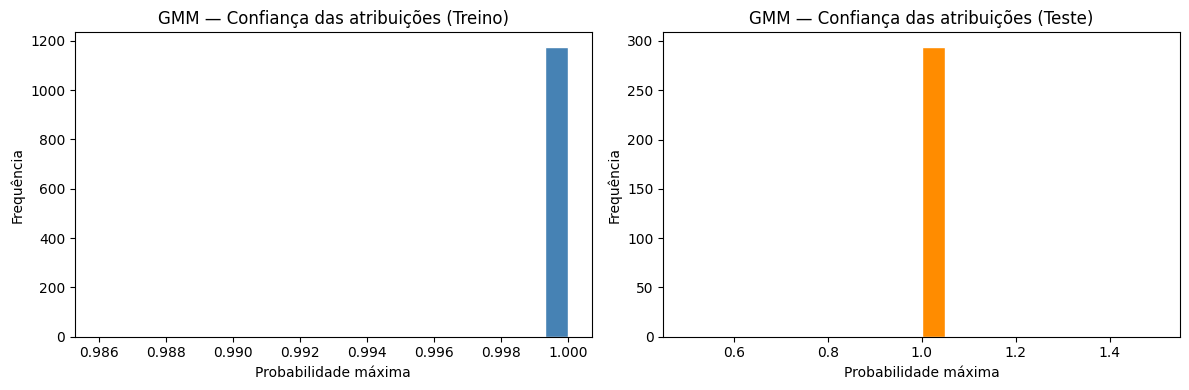

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(conf_train_gmm, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('GMM — Confiança das atribuições (Treino)')
axes[0].set_xlabel('Probabilidade máxima')
axes[0].set_ylabel('Frequência')

axes[1].hist(conf_test_gmm, bins=20, color='darkorange', edgecolor='white')
axes[1].set_title('GMM — Confiança das atribuições (Teste)')
axes[1].set_xlabel('Probabilidade máxima')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.savefig('gmm_confianca_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.5 Visualização PCA — GMM Treino vs. Teste

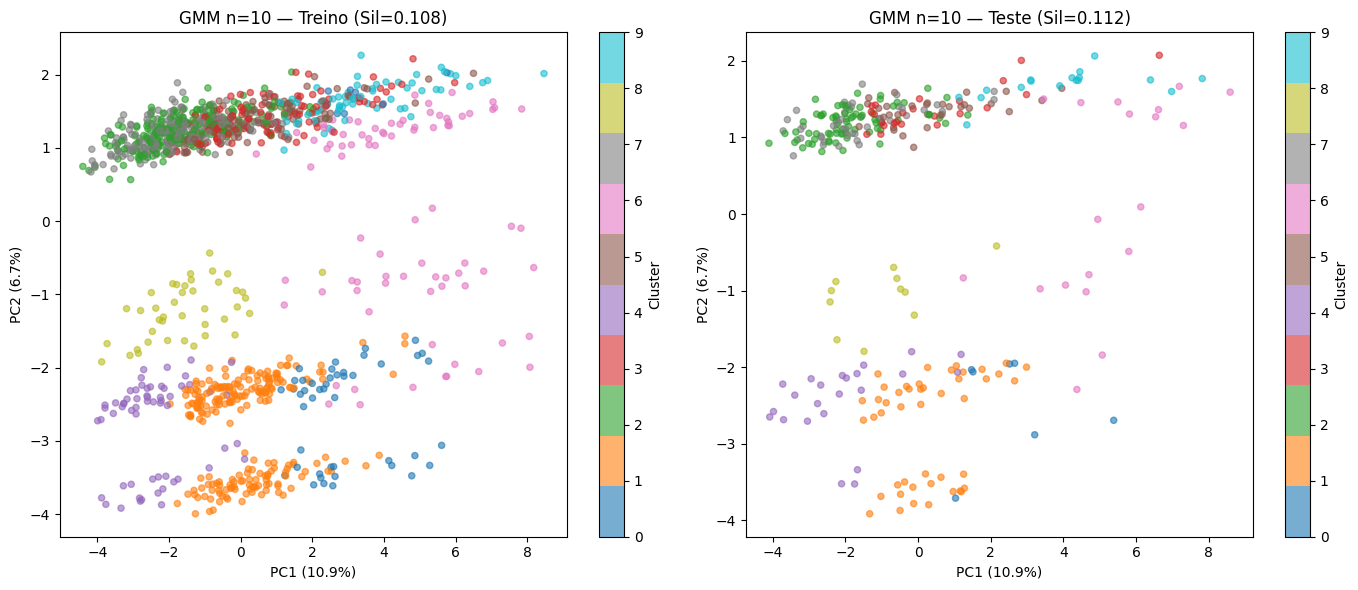

In [26]:
from sklearn.decomposition import PCA

pca_gmm = PCA(n_components=2, random_state=42)
X_train_pca_gmm = pca_gmm.fit_transform(X_train_scaled)
X_test_pca_gmm = pca_gmm.transform(X_test_scaled)
var_gmm = pca_gmm.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(
    X_train_pca_gmm[:, 0], X_train_pca_gmm[:, 1],
    c=clusters_train_gmm, cmap='tab10', alpha=0.6, s=20
)
axes[0].set_title(f'GMM n={melhor_n_gmm} — Treino (Sil={sil_train_gmm:.3f})')
axes[0].set_xlabel(f'PC1 ({var_gmm[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_gmm[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

sc2 = axes[1].scatter(
    X_test_pca_gmm[:, 0], X_test_pca_gmm[:, 1],
    c=clusters_test_gmm, cmap='tab10', alpha=0.6, s=20
)
axes[1].set_title(f'GMM n={melhor_n_gmm} — Teste (Sil={sil_test_gmm:.3f})')
axes[1].set_xlabel(f'PC1 ({var_gmm[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({var_gmm[1]*100:.1f}%)')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('gmm_pca_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.6 Distribuição dos Clusters — GMM Treino vs. Teste

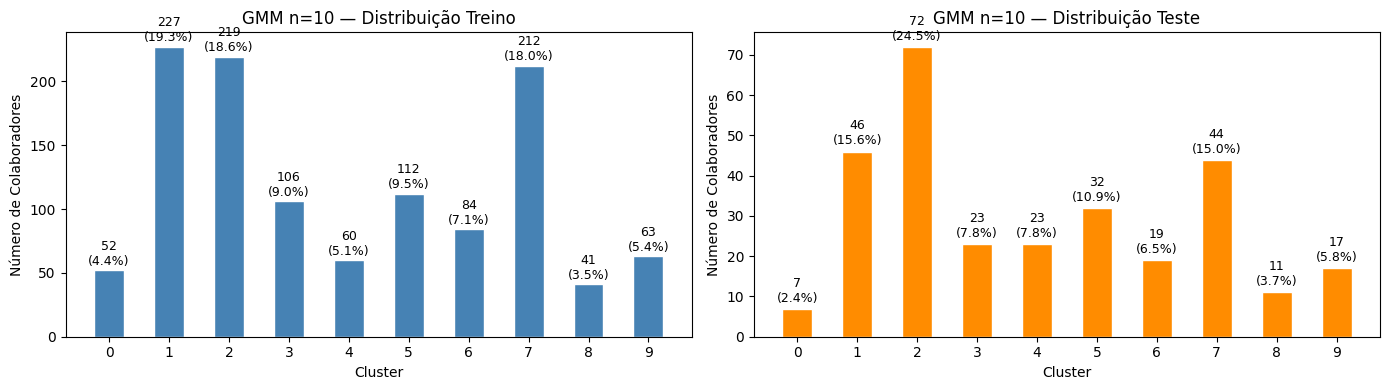

In [27]:
contagem_gmm_train = pd.Series(clusters_train_gmm).value_counts().sort_index()
contagem_gmm_test = pd.Series(clusters_test_gmm).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars1 = axes[0].bar(contagem_gmm_train.index, contagem_gmm_train.values,
                    color='steelblue', edgecolor='white', width=0.5)

for bar, val in zip(bars1, contagem_gmm_train.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'{val}\n({val/len(clusters_train_gmm)*100:.1f}%)',
        ha='center', va='bottom', fontsize=9
    )

axes[0].set_title(f'GMM n={melhor_n_gmm} — Distribuição Treino')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Número de Colaboradores')
axes[0].set_xticks(contagem_gmm_train.index)

bars2 = axes[1].bar(contagem_gmm_test.index, contagem_gmm_test.values,
                    color='darkorange', edgecolor='white', width=0.5)

for bar, val in zip(bars2, contagem_gmm_test.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val}\n({val/len(clusters_test_gmm)*100:.1f}%)',
        ha='center', va='bottom', fontsize=9
    )

axes[1].set_title(f'GMM n={melhor_n_gmm} — Distribuição Teste')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Número de Colaboradores')
axes[1].set_xticks(contagem_gmm_test.index)

plt.tight_layout()
plt.savefig('gmm_distribuicao_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.7 Silhouette Plot — GMM (Treino)

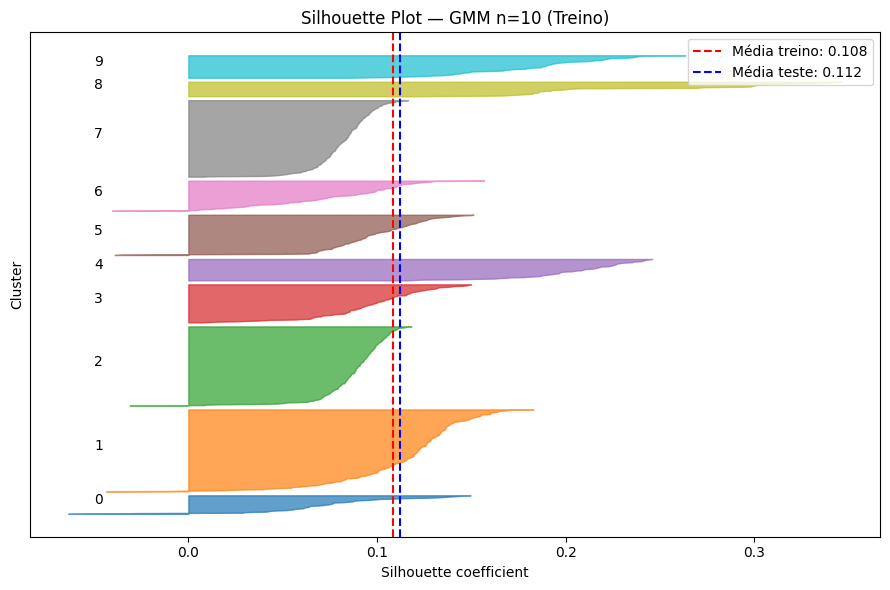

In [28]:
from sklearn.metrics import silhouette_samples
import numpy as np

sample_sil_gmm = silhouette_samples(X_train_scaled, clusters_train_gmm)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, melhor_n_gmm))

for i in range(melhor_n_gmm):
    vals = sample_sil_gmm[clusters_train_gmm == i]
    vals.sort()
    size = vals.shape[0]
    y_upper = y_lower + size
    
    ax.fill_betweenx(
        np.arange(y_lower, y_upper), 0, vals,
        facecolor=colors[i], edgecolor=colors[i], alpha=0.7
    )
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_train_gmm, color='red', linestyle='--', linewidth=1.5,
           label=f'Média treino: {sil_train_gmm:.3f}')
ax.axvline(sil_test_gmm, color='blue', linestyle='--', linewidth=1.5,
           label=f'Média teste: {sil_test_gmm:.3f}')

ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot — GMM n={melhor_n_gmm} (Treino)')
ax.set_yticks([])
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('silhouette_gmm_treino.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.8 Caracterização dos Clusters

In [29]:
df_gmm_perf = X_train.copy()
df_gmm_perf['Cluster'] = clusters_train_gmm

cols_perfil_gmm = [
    col for col in ['Age', 'MonthlyIncome', 'JobLevel', 'TotalWorkingYears',
                    'YearsAtCompany', 'SatisfactionIndex', 'WorkLifeBalance',
                    'OverTime_bin', 'IncomePerLevel', 'RatioYearsInRole']
    if col in df_gmm_perf.columns
]

perfil_gmm = df_gmm_perf.groupby('Cluster')[cols_perfil_gmm].mean().round(3)

print("===== PERFIL MÉDIO POR CLUSTER — GMM =====")
display(perfil_gmm)

===== PERFIL MÉDIO POR CLUSTER — GMM =====


,Age,MonthlyIncome,JobLevel,TotalWorkingYears,YearsAtCompany,SatisfactionIndex,WorkLifeBalance,OverTime_bin,IncomePerLevel,RatioYearsInRole
Cluster,,,,,,,,,,
0,40.346,7972.096,2.615,15.750,13.173,2.212,2.865,0.231,3034.925,0.728
1,36.225,6697.546,2.273,10.291,6.454,2.137,2.802,0.295,2928.503,0.604
2,34.338,3300.384,1.224,8.032,5.269,2.183,2.680,0.329,2744.323,0.578
3,39.726,7505.500,2.472,13.726,8.462,2.208,2.689,0.283,3016.819,0.565
4,29.433,2591.483,1.067,4.267,2.700,2.233,2.933,0.267,2454.575,0.532
5,38.321,7256.482,2.438,12.661,7.536,2.170,2.777,0.277,2927.731,0.632
6,47.250,16941.333,4.238,24.690,14.179,2.119,2.750,0.310,4015.625,0.473
7,33.925,3255.443,1.241,7.552,4.783,2.146,2.693,0.264,2713.579,0.552
8,35.488,4040.512,1.415,7.439,4.829,2.122,2.902,0.244,2816.020,0.606


## 9. Candidato 4 — Agglomerative Clustering

Algoritmo que utiliza uma estratégia bottom-up: cada observação começa no seu próprio cluster e os pares de clusters são mesclados sucessivamente à medida que se sobe na hierarquia.

### 9.1 Treino do modelo (Treino)

In [30]:
from sklearn.cluster import AgglomerativeClustering

n_clusters_hc = melhor_k

hc = AgglomerativeClustering(
    n_clusters=n_clusters_hc,
    linkage='ward'
)

clusters_train_hc = hc.fit_predict(X_train_scaled)

### 9.2 Aplicação ao Teste

In [31]:
from sklearn.neighbors import KNeighborsClassifier

knn_hc = KNeighborsClassifier(n_neighbors=5)
knn_hc.fit(X_train_scaled, clusters_train_hc)

clusters_test_hc = knn_hc.predict(X_test_scaled)

### 9.3 Métricas

In [32]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# TREINO
sil_train_hc = silhouette_score(X_train_scaled, clusters_train_hc)
db_train_hc = davies_bouldin_score(X_train_scaled, clusters_train_hc)
ch_train_hc = calinski_harabasz_score(X_train_scaled, clusters_train_hc)

# TESTE
sil_test_hc = silhouette_score(X_test_scaled, clusters_test_hc)
db_test_hc = davies_bouldin_score(X_test_scaled, clusters_test_hc)
ch_test_hc = calinski_harabasz_score(X_test_scaled, clusters_test_hc)

print("===== HIERÁRQUICO — TREINO vs TESTE =====")
print(f"{'Métrica':<25} {'Treino':>10} {'Teste':>10} {'Diferença':>12}")
print("-"*60)
print(f"{'Silhouette Score':<25} {sil_train_hc:>10.4f} {sil_test_hc:>10.4f} {abs(sil_train_hc-sil_test_hc):>12.4f}")
print(f"{'Davies-Bouldin':<25} {db_train_hc:>10.4f} {db_test_hc:>10.4f} {abs(db_train_hc-db_test_hc):>12.4f}")
print(f"{'Calinski-Harabasz':<25} {ch_train_hc:>10.2f} {ch_test_hc:>10.2f} {abs(ch_train_hc-ch_test_hc):>12.2f}")

print(f"\nMeta Silhouette > 0.50 (Treino): {'ATINGIDA' if sil_train_hc > 0.50 else 'NÃO ATINGIDA'}")
print(f"Meta Silhouette > 0.50 (Teste): {'ATINGIDA' if sil_test_hc > 0.50 else 'NÃO ATINGIDA'}")

===== HIERÁRQUICO — TREINO vs TESTE =====
Métrica                       Treino      Teste    Diferença
------------------------------------------------------------
Silhouette Score              0.0940     0.1000       0.0060
Davies-Bouldin                2.4149     2.1909       0.2241
Calinski-Harabasz              51.61      14.66        36.95

Meta Silhouette > 0.50 (Treino): NÃO ATINGIDA
Meta Silhouette > 0.50 (Teste): NÃO ATINGIDA


### 9.4 PCA

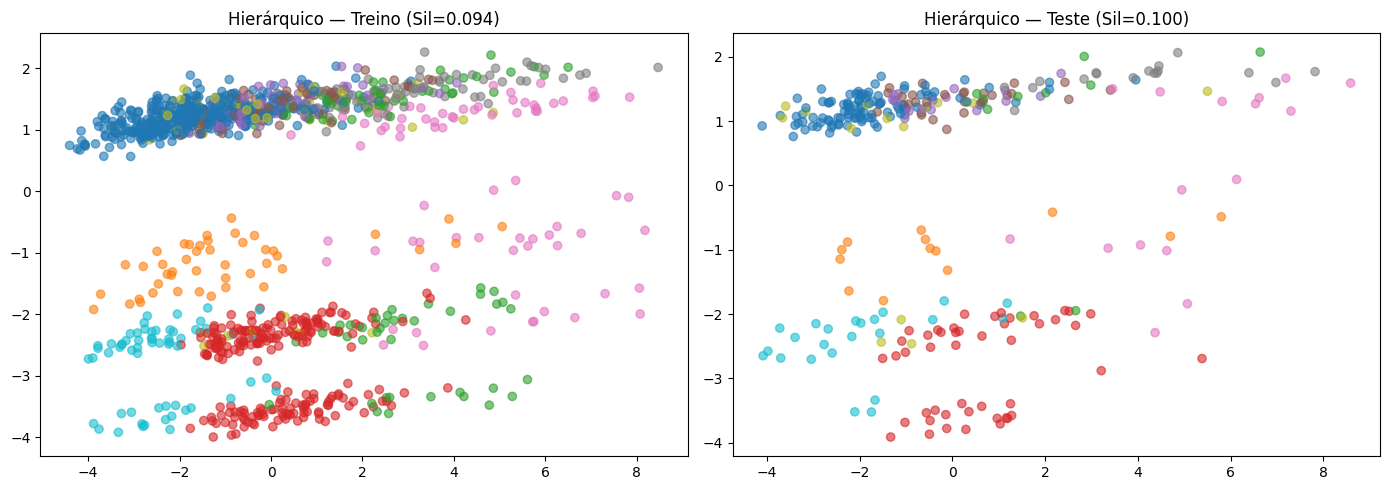

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_train_pca_hc = pca.fit_transform(X_train_scaled)
X_test_pca_hc = pca.transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_train_pca_hc[:, 0], X_train_pca_hc[:, 1],
                c=clusters_train_hc, cmap='tab10', alpha=0.6)
axes[0].set_title(f'Hierárquico — Treino (Sil={sil_train_hc:.3f})')

axes[1].scatter(X_test_pca_hc[:, 0], X_test_pca_hc[:, 1],
                c=clusters_test_hc, cmap='tab10', alpha=0.6)
axes[1].set_title(f'Hierárquico — Teste (Sil={sil_test_hc:.3f})')

plt.tight_layout()
plt.show()

### 9.5 Dendrograma

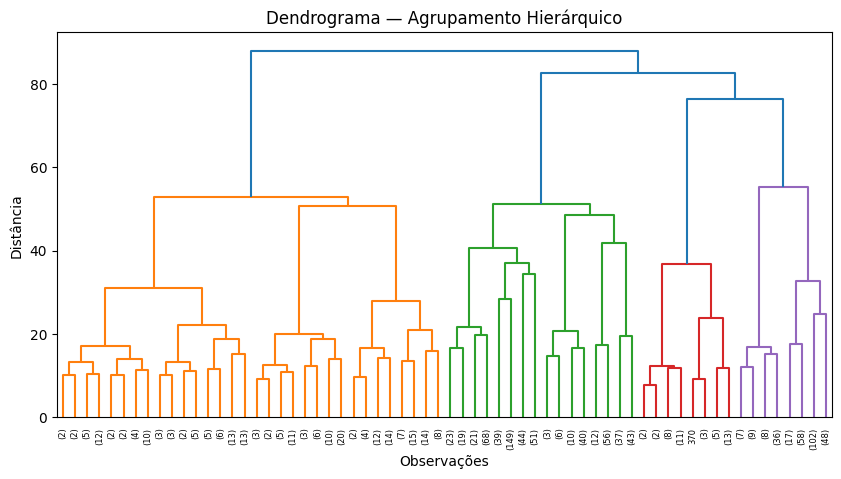

In [34]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_train_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Dendrograma — Agrupamento Hierárquico")
plt.xlabel("Observações")
plt.ylabel("Distância")
plt.show()

## 10. Candidato 5 — OPTICS

Extensão do DBSCAN que aborda uma das suas principais fraquezas: a dificuldade em detectar clusters de densidades variadas.

### 10.1 Treino do modelo (Treino)

In [35]:
from sklearn.cluster import OPTICS

optics = OPTICS(
    min_samples=5,
    xi=0.05,          
    min_cluster_size=0.05 
)

clusters_train_opt = optics.fit_predict(X_train_scaled)

### 10.2 Diagnóstico inicial

In [36]:
import numpy as np

n_clusters_opt = len(set(clusters_train_opt)) - (1 if -1 in clusters_train_opt else 0)
noise_opt = np.sum(clusters_train_opt == -1)
noise_pct_opt = noise_opt / len(clusters_train_opt) * 100

print("OPTICS TREINO:")
print(f"Clusters encontrados: {n_clusters_opt}")
print(f"Ruído: {noise_opt} ({noise_pct_opt:.1f}%)")
print("\nDistribuição:")
print(pd.Series(clusters_train_opt).value_counts().sort_index())

OPTICS TREINO:
Clusters encontrados: 1
Ruído: 0 (0.0%)

Distribuição:
0    1176
Name: count, dtype: int64


### 10.3 Aplicação ao Teste

In [37]:
from sklearn.neighbors import KNeighborsClassifier

mask_train_opt = clusters_train_opt != -1

knn_opt = KNeighborsClassifier(n_neighbors=5)
knn_opt.fit(X_train_scaled[mask_train_opt], clusters_train_opt[mask_train_opt])

clusters_test_opt = knn_opt.predict(X_test_scaled)

### 10.4 Métricas

In [38]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# remover ruído
mask = clusters_train_opt != -1

if len(set(clusters_train_opt[mask])) > 1:
    sil_train_opt = silhouette_score(X_train_scaled[mask], clusters_train_opt[mask])
    db_train_opt = davies_bouldin_score(X_train_scaled[mask], clusters_train_opt[mask])
    ch_train_opt = calinski_harabasz_score(X_train_scaled[mask], clusters_train_opt[mask])
else:
    sil_train_opt = db_train_opt = ch_train_opt = np.nan

# TESTE
if len(set(clusters_test_opt)) > 1:
    sil_test_opt = silhouette_score(X_test_scaled, clusters_test_opt)
    db_test_opt = davies_bouldin_score(X_test_scaled, clusters_test_opt)
    ch_test_opt = calinski_harabasz_score(X_test_scaled, clusters_test_opt)
else:
    sil_test_opt = db_test_opt = ch_test_opt = np.nan

print("===== OPTICS — TREINO vs TESTE =====")
print(f"{'Métrica':<25} {'Treino':>10} {'Teste':>10} {'Diferença':>12}")
print("-"*60)
print(f"{'Silhouette Score':<25} {sil_train_opt:>10.4f} {sil_test_opt:>10.4f} {abs(sil_train_opt-sil_test_opt):>12.4f}")
print(f"{'Davies-Bouldin':<25} {db_train_opt:>10.4f} {db_test_opt:>10.4f} {abs(db_train_opt-db_test_opt):>12.4f}")
print(f"{'Calinski-Harabasz':<25} {ch_train_opt:>10.2f} {ch_test_opt:>10.2f} {abs(ch_train_opt-ch_test_opt):>12.2f}")

print(f"\nMeta Silhouette > 0.50 (Treino): {'ATINGIDA' if sil_train_opt > 0.50 else 'NÃO ATINGIDA'}")
print(f"Meta Silhouette > 0.50 (Teste): {'ATINGIDA' if sil_test_opt > 0.50 else 'NÃO ATINGIDA'}")

===== OPTICS — TREINO vs TESTE =====
Métrica                       Treino      Teste    Diferença
------------------------------------------------------------
Silhouette Score                 nan        nan          nan
Davies-Bouldin                   nan        nan          nan
Calinski-Harabasz                nan        nan          nan

Meta Silhouette > 0.50 (Treino): NÃO ATINGIDA
Meta Silhouette > 0.50 (Teste): NÃO ATINGIDA


### 10.5 PCA

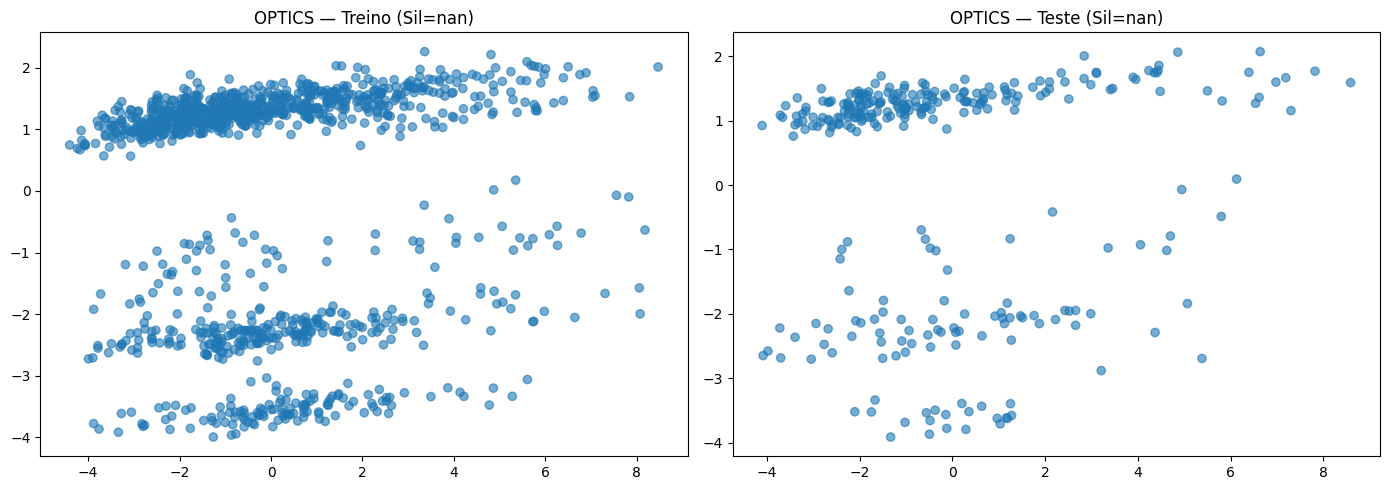

In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_train_pca_opt = pca.fit_transform(X_train_scaled)
X_test_pca_opt = pca.transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_train_pca_opt[:, 0], X_train_pca_opt[:, 1],
                c=clusters_train_opt, cmap='tab10', alpha=0.6)
axes[0].set_title(f'OPTICS — Treino (Sil={sil_train_opt:.3f})')

axes[1].scatter(X_test_pca_opt[:, 0], X_test_pca_opt[:, 1],
                c=clusters_test_opt, cmap='tab10', alpha=0.6)
axes[1].set_title(f'OPTICS — Teste (Sil={sil_test_opt:.3f})')

plt.tight_layout()
plt.show()

### 10.6 Distribuição dos clusters

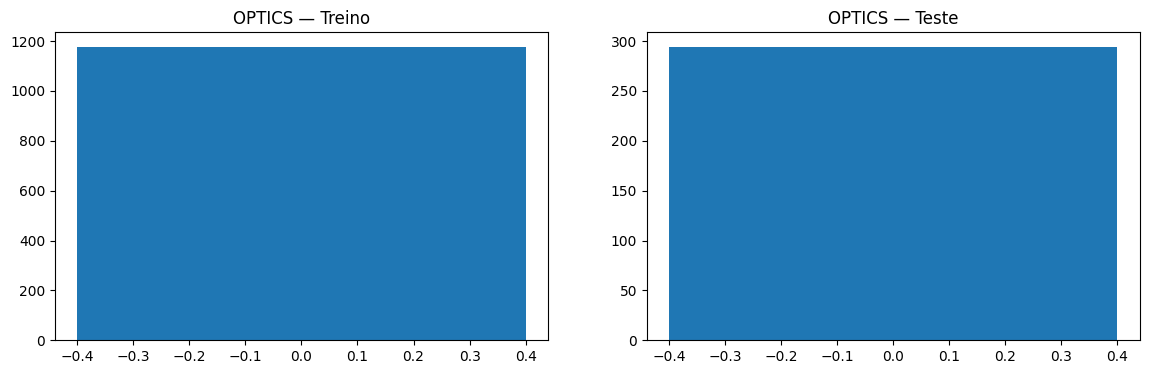

In [40]:
contagem_train = pd.Series(clusters_train_opt).value_counts().sort_index()
contagem_test = pd.Series(clusters_test_opt).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(contagem_train.index, contagem_train.values)
axes[0].set_title("OPTICS — Treino")

axes[1].bar(contagem_test.index, contagem_test.values)
axes[1].set_title("OPTICS — Teste")

plt.show()

O algoritmo OPTICS não identificou múltiplos clusters, atribuindo todas as observações a um único grupo.

## 11. Candidato 6 — MiniBatch K-Means

Uma variante otimizada do K-Means clássico que utiliza pequenos lotes (batches) de dados selecionados aleatoriamente para atualizar os centroides em cada iteração.

### 11.1 Treino do modelo

In [41]:
from sklearn.cluster import MiniBatchKMeans

mbkm = MiniBatchKMeans(
    n_clusters=melhor_k, 
    random_state=42,
    batch_size=64,
    n_init=10
)

clusters_train_mb = mbkm.fit_predict(X_train_scaled)
clusters_test_mb = mbkm.predict(X_test_scaled)

### 11.2 Métricas treino vs teste

In [42]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

# TREINO
sil_train_mb = silhouette_score(X_train_scaled, clusters_train_mb)
db_train_mb = davies_bouldin_score(X_train_scaled, clusters_train_mb)
ch_train_mb = calinski_harabasz_score(X_train_scaled, clusters_train_mb)

# TESTE
sil_test_mb = silhouette_score(X_test_scaled, clusters_test_mb)
db_test_mb = davies_bouldin_score(X_test_scaled, clusters_test_mb)
ch_test_mb = calinski_harabasz_score(X_test_scaled, clusters_test_mb)

print("===== MINIBATCH K-MEANS — TREINO vs TESTE =====")
print(f"{'Métrica':<25} {'Treino':>10} {'Teste':>10} {'Diferença':>12}")
print("-"*60)
print(f"{'Silhouette Score':<25} {sil_train_mb:>10.4f} {sil_test_mb:>10.4f} {abs(sil_train_mb-sil_test_mb):>12.4f}")
print(f"{'Davies-Bouldin':<25} {db_train_mb:>10.4f} {db_test_mb:>10.4f} {abs(db_train_mb-db_test_mb):>12.4f}")
print(f"{'Calinski-Harabasz':<25} {ch_train_mb:>10.2f} {ch_test_mb:>10.2f} {abs(ch_train_mb-ch_test_mb):>12.2f}")

print(f"\nMeta Silhouette > 0.50 (Treino): {'ATINGIDA' if sil_train_mb > 0.50 else 'NÃO ATINGIDA'}")
print(f"Meta Silhouette > 0.50 (Teste): {'ATINGIDA' if sil_test_mb > 0.50 else 'NÃO ATINGIDA'}")

print("\nDistribuição clusters — Treino:")
print(pd.Series(clusters_train_mb).value_counts().sort_index().to_string())

print("\nDistribuição clusters — Teste:")
print(pd.Series(clusters_test_mb).value_counts().sort_index().to_string())

===== MINIBATCH K-MEANS — TREINO vs TESTE =====
Métrica                       Treino      Teste    Diferença
------------------------------------------------------------
Silhouette Score              0.0867     0.0868       0.0002
Davies-Bouldin                2.6217     2.4368       0.1849
Calinski-Harabasz              55.71      15.37        40.34

Meta Silhouette > 0.50 (Treino): NÃO ATINGIDA
Meta Silhouette > 0.50 (Teste): NÃO ATINGIDA

Distribuição clusters — Treino:
0     84
1    106
2     41
3    180
4    202
5    206
6     94
7     63
8     60
9    140

Distribuição clusters — Teste:
0    19
1    22
2    11
3    49
4    40
5    67
6    18
7    17
8    23
9    28


### 11.3 Visualização PCA — treino vs teste

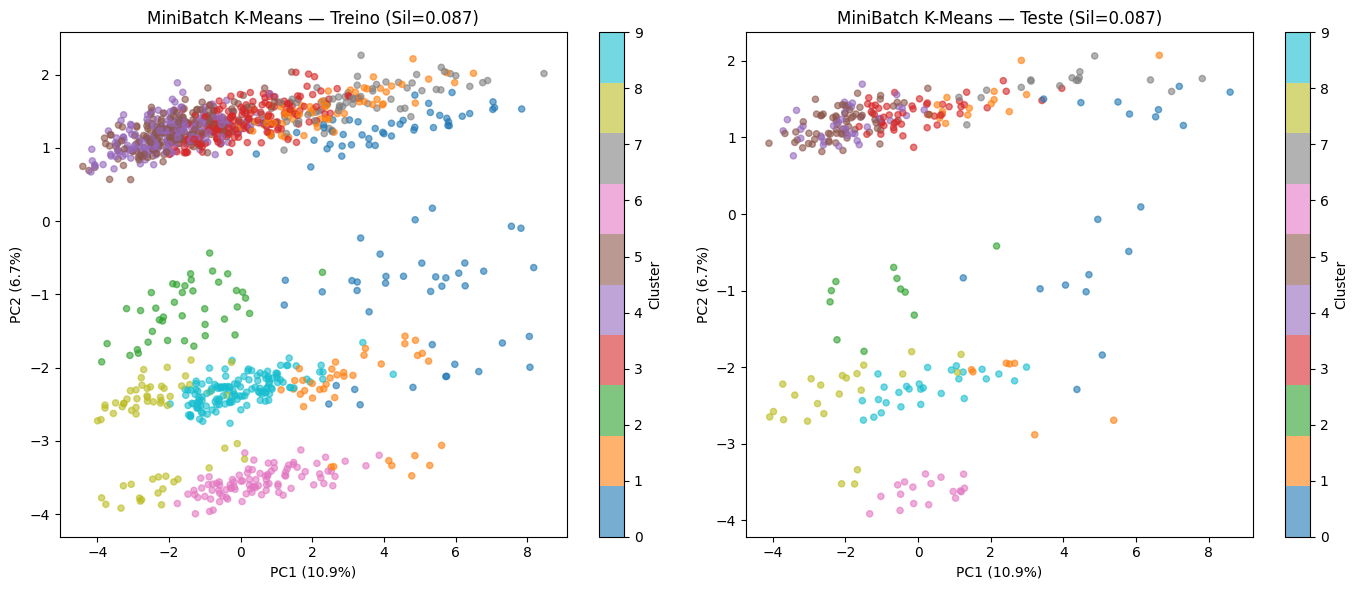

In [43]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_mb = PCA(n_components=2, random_state=42)
X_train_pca_mb = pca_mb.fit_transform(X_train_scaled)
X_test_pca_mb = pca_mb.transform(X_test_scaled)
var_mb = pca_mb.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(
    X_train_pca_mb[:, 0], X_train_pca_mb[:, 1],
    c=clusters_train_mb, cmap='tab10', alpha=0.6, s=20
)
axes[0].set_title(f'MiniBatch K-Means — Treino (Sil={sil_train_mb:.3f})')
axes[0].set_xlabel(f'PC1 ({var_mb[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_mb[1]*100:.1f}%)')
plt.colorbar(sc1, ax=axes[0], label='Cluster')

sc2 = axes[1].scatter(
    X_test_pca_mb[:, 0], X_test_pca_mb[:, 1],
    c=clusters_test_mb, cmap='tab10', alpha=0.6, s=20
)
axes[1].set_title(f'MiniBatch K-Means — Teste (Sil={sil_test_mb:.3f})')
axes[1].set_xlabel(f'PC1 ({var_mb[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({var_mb[1]*100:.1f}%)')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('minibatch_kmeans_pca_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.4 Distribuição dos clusters

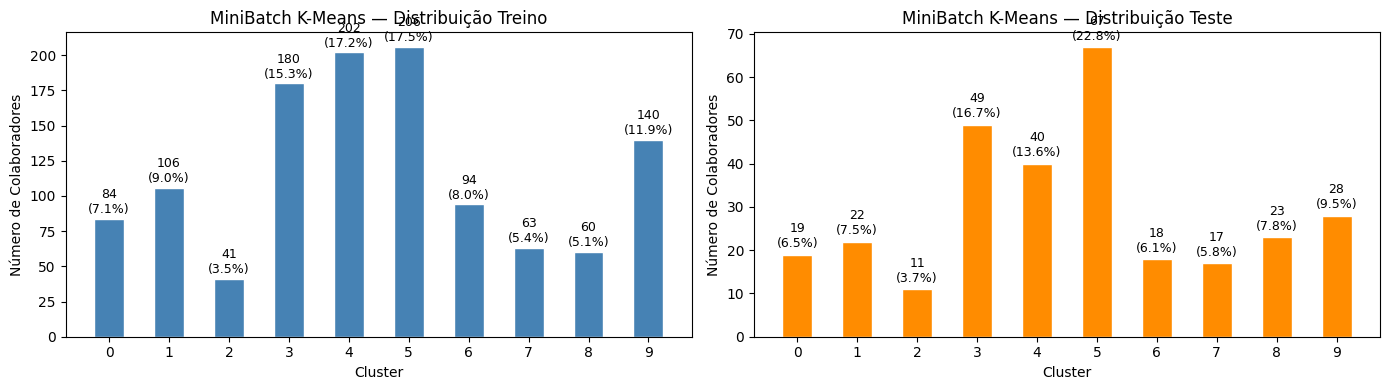

In [44]:
contagem_mb_train = pd.Series(clusters_train_mb).value_counts().sort_index()
contagem_mb_test = pd.Series(clusters_test_mb).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bars1 = axes[0].bar(contagem_mb_train.index, contagem_mb_train.values,
                    color='steelblue', edgecolor='white', width=0.5)

for bar, val in zip(bars1, contagem_mb_train.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'{val}\n({val/len(clusters_train_mb)*100:.1f}%)',
        ha='center', va='bottom', fontsize=9
    )

axes[0].set_title('MiniBatch K-Means — Distribuição Treino')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Número de Colaboradores')
axes[0].set_xticks(contagem_mb_train.index)

bars2 = axes[1].bar(contagem_mb_test.index, contagem_mb_test.values,
                    color='darkorange', edgecolor='white', width=0.5)

for bar, val in zip(bars2, contagem_mb_test.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val}\n({val/len(clusters_test_mb)*100:.1f}%)',
        ha='center', va='bottom', fontsize=9
    )

axes[1].set_title('MiniBatch K-Means — Distribuição Teste')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Número de Colaboradores')
axes[1].set_xticks(contagem_mb_test.index)

plt.tight_layout()
plt.savefig('minibatch_kmeans_distribuicao_treino_teste.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.5 Silhouette plot — treino

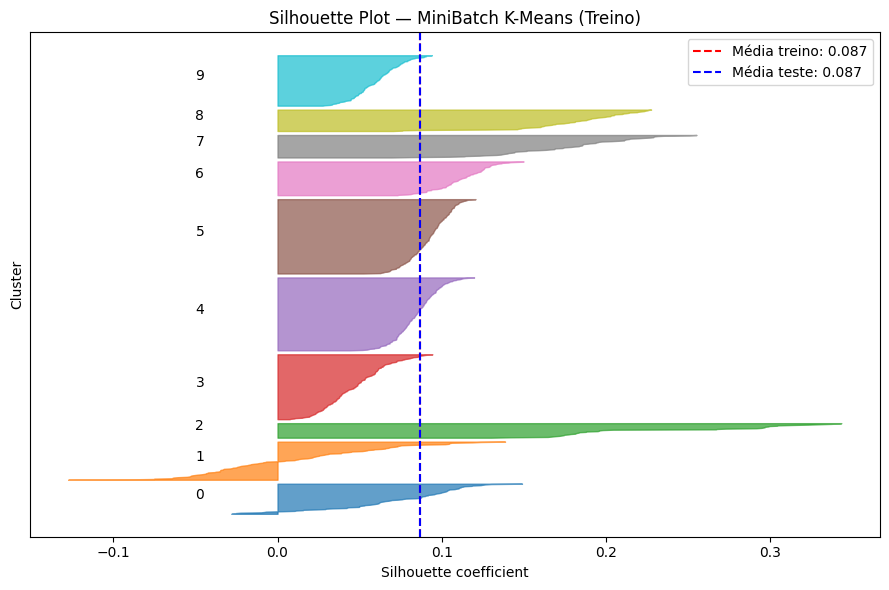

In [45]:
from sklearn.metrics import silhouette_samples

sample_sil_mb = silhouette_samples(X_train_scaled, clusters_train_mb)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, melhor_k))

for i in range(melhor_k):
    vals = sample_sil_mb[clusters_train_mb == i]
    vals.sort()
    size = vals.shape[0]
    y_upper = y_lower + size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper), 0, vals,
        facecolor=colors[i], edgecolor=colors[i], alpha=0.7
    )
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_train_mb, color='red', linestyle='--', linewidth=1.5,
           label=f'Média treino: {sil_train_mb:.3f}')
ax.axvline(sil_test_mb, color='blue', linestyle='--', linewidth=1.5,
           label=f'Média teste: {sil_test_mb:.3f}')

ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot — MiniBatch K-Means (Treino)')
ax.set_yticks([])
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('silhouette_minibatch_kmeans_treino.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.6 Caracterização dos clusters

In [46]:
df_mb_perf = X_train.copy()
df_mb_perf['Cluster'] = clusters_train_mb

cols_perfil_mb = [
    col for col in ['Age', 'MonthlyIncome', 'JobLevel', 'TotalWorkingYears',
                    'YearsAtCompany', 'SatisfactionIndex', 'WorkLifeBalance',
                    'OverTime_bin', 'IncomePerLevel', 'RatioYearsInRole']
    if col in df_mb_perf.columns
]

perfil_mb = df_mb_perf.groupby('Cluster')[cols_perfil_mb].mean().round(3)

print("===== PERFIL MÉDIO POR CLUSTER — MINIBATCH K-MEANS =====")
display(perfil_mb)

===== PERFIL MÉDIO POR CLUSTER — MINIBATCH K-MEANS =====


,Age,MonthlyIncome,JobLevel,TotalWorkingYears,YearsAtCompany,SatisfactionIndex,WorkLifeBalance,OverTime_bin,IncomePerLevel,RatioYearsInRole
Cluster,,,,,,,,,,
0,47.250,16941.333,4.238,24.690,14.179,2.119,2.750,0.310,4015.625,0.473
1,39.887,7766.962,2.547,16.472,13.557,2.170,2.774,0.349,3016.495,0.729
2,35.488,4040.512,1.415,7.439,4.829,2.122,2.902,0.244,2816.020,0.606
3,38.694,7069.761,2.372,12.206,6.694,2.183,2.728,0.244,2950.052,0.571
4,33.733,3185.223,1.218,7.292,4.465,2.149,2.693,0.262,2707.897,0.539
5,34.180,3229.117,1.199,7.762,4.942,2.194,2.675,0.320,2740.354,0.562
6,37.777,6808.787,2.287,10.926,6.521,2.245,2.809,0.330,2960.800,0.623
7,44.190,15800.190,3.905,21.302,10.810,2.127,2.825,0.317,4078.149,0.584
8,29.433,2591.483,1.067,4.267,2.700,2.233,2.933,0.267,2454.575,0.532


In [47]:
import pandas as pd
import numpy as np

# ================================
# TABELA FINAL — COMPARAÇÃO MODELOS
# ================================

resultados_finais = pd.DataFrame([
    {
        "Modelo": "K-Means Baseline",
        "Treino_Silhouette": sil_train_base,
        "Teste_Silhouette": sil_test_base,
        "Treino_DB": db_train_base,
        "Teste_DB": db_test_base,
        "Treino_CH": ch_train_base,
        "Teste_CH": ch_test_base,
        "Meta_Silhouette_0.50": "Sim" if sil_test_base > 0.50 else "Não"
    },
    {
        "Modelo": f"K-Means Otimizado (k={melhor_k})",
        "Treino_Silhouette": sil_train_km,
        "Teste_Silhouette": sil_test_km,
        "Treino_DB": db_train_km,
        "Teste_DB": db_test_km,
        "Treino_CH": ch_train_km,
        "Teste_CH": ch_test_km,
        "Meta_Silhouette_0.50": "Sim" if sil_test_km > 0.50 else "Não"
    },
    {
        "Modelo": f"DBSCAN (eps={eps_value})",
        "Treino_Silhouette": sil_train_db,
        "Teste_Silhouette": sil_test_db,
        "Treino_DB": db_train_db,
        "Teste_DB": db_test_db,
        "Treino_CH": ch_train_db,
        "Teste_CH": ch_test_db,
        "Meta_Silhouette_0.50": "Sim" if sil_test_db > 0.50 else "Não"
    },
    {
        "Modelo": f"GMM (n={melhor_n_gmm})",
        "Treino_Silhouette": sil_train_gmm,
        "Teste_Silhouette": sil_test_gmm,
        "Treino_DB": db_train_gmm,
        "Teste_DB": db_test_gmm,
        "Treino_CH": ch_train_gmm,
        "Teste_CH": ch_test_gmm,
        "Meta_Silhouette_0.50": "Sim" if sil_test_gmm > 0.50 else "Não"
    },
    {
        "Modelo": f"Hierárquico (k={n_clusters_hc})",
        "Treino_Silhouette": sil_train_hc,
        "Teste_Silhouette": sil_test_hc,
        "Treino_DB": db_train_hc,
        "Teste_DB": db_test_hc,
        "Treino_CH": ch_train_hc,
        "Teste_CH": ch_test_hc,
        "Meta_Silhouette_0.50": "Sim" if sil_test_hc > 0.50 else "Não"
    },
    {
        "Modelo": f"MiniBatch K-Means (k={melhor_k})",
        "Treino_Silhouette": sil_train_mb,
        "Teste_Silhouette": sil_test_mb,
        "Treino_DB": db_train_mb,
        "Teste_DB": db_test_mb,
        "Treino_CH": ch_train_mb,
        "Teste_CH": ch_test_mb,
        "Meta_Silhouette_0.50": "Sim" if sil_test_mb > 0.50 else "Não"
    }
])

# Arredondar métricas
cols_metricas = [
    "Treino_Silhouette", "Teste_Silhouette",
    "Treino_DB", "Teste_DB",
    "Treino_CH", "Teste_CH"
]
resultados_finais[cols_metricas] = resultados_finais[cols_metricas].round(4)

# Diferença treino vs teste (estabilidade)
resultados_finais["Dif_Silhouette"] = (
    resultados_finais["Treino_Silhouette"] - resultados_finais["Teste_Silhouette"]
).abs().round(4)

# Ordenação principal:
# 1) maior silhouette em teste
# 2) menor Davies-Bouldin em teste
resultados_finais = resultados_finais.sort_values(
    by=["Teste_Silhouette", "Teste_DB"],
    ascending=[False, True]
).reset_index(drop=True)

print("===== TABELA FINAL — COMPARAÇÃO DE MODELOS DE CLUSTERING =====")
display(resultados_finais)

===== TABELA FINAL — COMPARAÇÃO DE MODELOS DE CLUSTERING =====


,Modelo,Treino_Silhouette,Teste_Silhouette,Treino_DB,Teste_DB,Treino_CH,Teste_CH,Meta_Silhouette_0.50,Dif_Silhouette
0,DBSCAN (eps=8.0),0.1761,0.1719,1.5601,1.5244,34.6125,8.9034,Não,0.0042
1,GMM (n=10),0.1083,0.1121,2.4249,2.2554,57.1211,15.8939,Não,0.0038
2,K-Means Otimizado (k=10),0.1092,0.1101,2.4058,2.2730,57.7903,16.1032,Não,0.0009
3,Hierárquico (k=10),0.0940,0.1000,2.4149,2.1909,51.6096,14.6601,Não,0.0060
4,MiniBatch K-Means (k=10),0.0867,0.0868,2.6217,2.4368,55.7104,15.3718,Não,0.0001
5,K-Means Baseline,0.0790,0.0786,3.0400,2.8650,59.9748,16.9906,Não,0.0004


### Seleção do Modelo Final

Com base na análise comparativa dos diferentes algoritmos de clustering, o modelo **DBSCAN** foi selecionado como o mais adequado para este problema.

Esta decisão foi suportada por uma avaliação conjunta de múltiplas métricas de desempenho. Em particular, o DBSCAN apresentou o **maior Silhouette Score em teste**, indicando a melhor relação entre coesão interna e separação entre clusters, ainda que abaixo da meta inicialmente definida. Adicionalmente, obteve o **menor valor de Davies-Bouldin**, evidenciando menor sobreposição entre grupos e, consequentemente, maior qualidade relativa da segmentação.

Embora o modelo não apresente o valor mais elevado na métrica **Calinski-Harabasz**, que favorece algoritmos que maximizam a separação global entre clusters, considerou-se que esta métrica, isoladamente, não é suficiente para capturar a qualidade estrutural dos agrupamentos, sendo mais relevante privilegiar métricas que penalizam sobreposição e incoerência interna dos clusters.

Para além do desempenho quantitativo, o DBSCAN demonstrou **elevada estabilidade entre treino e teste**, sugerindo boa capacidade de generalização. Adicionalmente, a sua capacidade de identificar automaticamente pontos de ruído constitui uma vantagem relevante na deteção de perfis atípicos de colaboradores, com potencial interesse para análise de risco de atrito.

Assim, o modelo DBSCAN foi selecionado como o mais adequado, não apenas pelo seu desempenho relativo, mas também pela sua interpretação prática. Este modelo será utilizado na fase seguinte para **otimização de hiperparâmetros (tuning)**, com o objetivo de melhorar a qualidade dos agrupamentos e explorar possíveis ganhos adicionais de desempenho.